# Predicting ECtHR Article 6 Violations: Coverage, Provenance, and the Limits of Legal Signal

**Project:** *Evaluating Legal Reasoning and Spurious Correlations in NLP Models of the European Court of Human Rights*

> *In the pursuit of judicial efficiency, does deploying predictive AI improve the legal system, or does it fundamentally erode the epistemological definition of what it means to 'judge'?*

**Refined Research Question:** *What textual patterns in ECtHR ‘Facts’ sections are most predictive of violation outcomes, and to what extent do they reflect legally meaningful reasoning rather than provenance-driven shortcuts?*

This notebook continues from our Exploratory Data Analysis to conduct both **topic modelling** and **predictive classification modelling**. It walks through the full modelling pipeline end-to-end:

1. Data loading (Article 6 subset)
2. Exploratory analysis of the Article 6 corpus (TF-IDF + Proportion Shift)
3. Topic modelling (NMF) — latent thematic clusters
4. TF-IDF + SVM / LogReg baseline
5. Document coverage analysis — why coverage determines performance
6. SVM at different token budgets
7. LegalBERT fine-tuning (512-token and Chunked 4× sliding window)
8. Model performance and per-country evaluation
9. Model signal analysis — SVM weights, LIME, error analysis, country-masking probes

> **Key framing:** the model performance table is a supporting artefact, not the main argument. Both SVM and LegalBERT pass ~70% Macro-F1, which is respectable for a small, class-imbalanced corpus. The substantive question is *what signal* the models use — legal reasoning, or geographic / procedural shortcuts. §11 answers this with SVM weights and LIME.

**Result loading priority (per model):**
1. Load from saved `results/<model>/test_probs.npz` and `training.log` — no GPU needed
2. Set `FORCE_RETRAIN = True` in §1 to retrain from scratch (requires GPU)


In [1]:
# ── Colab setup: clone repo and symlink data/results if running on Google Colab ──
import os, sys

IN_COLAB = 'google.colab' in sys.modules
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess, shutil
    REPO = 'https://github.com/leondgarse/echr.git'
    CLONE_DIR = '/content/echr_repo'

    if not os.path.exists(CLONE_DIR):
        print(f'Cloning {REPO} ...')
        subprocess.run(['git', 'clone', '--depth', '1', REPO, CLONE_DIR], check=True)
    else:
        print(f'Repo already cloned at {CLONE_DIR}')

    # Move data/ and results/ into the working directory if not already there
    for folder in ['data', 'results']:
        src = os.path.join(CLONE_DIR, folder)
        dst = os.path.join('/content', folder)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copytree(src, dst)
            print(f'Copied {src} → {dst}')
        elif os.path.exists(dst):
            print(f'{dst} already exists, skipping.')
        else:
            print(f'WARNING: {src} not found in cloned repo.')

    # Change working directory to /content so relative paths work
    os.chdir('/content')
    print(f'Working directory: {os.getcwd()}')
    print('Colab setup complete.')
else:
    print('Not running in Colab — no setup needed.')


Not running in Colab — no setup needed.


In [2]:
# Install any missing dependencies
%pip install -q lime spacy seaborn
import subprocess, sys
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm', '--quiet'],
               capture_output=True)


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


CompletedProcess(args=['/home/leondgarse/virtualenvs/workon312/bin/python3', '-m', 'spacy', 'download', 'en_core_web_sm', '--quiet'], returncode=0, stdout=b"\x1b\xe2\x9c\x94 Download and installation successful\x1b\nYou can now load the package via spacy.load('en_core_web_sm')\n", stderr=b'\n\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b A new release of pip is available: \x1b\x1b26.0\x1b\x1b -> \x1b\x1b26.0.1\x1b\n\x1b[\x1b\x1bnotice\x1b\x1b[1;39;49m]\x1b\x1b To update, run: \x1b\x1bpip install --upgrade pip\x1b\n')

In [3]:
%matplotlib inline
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup, set_seed as hf_set_seed,
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')
print('All imports OK')

All imports OK


## 1. Configuration

**Starting data (from EDA):** We found Articles 3, 5 and 8 are not evenly distributed across the three countries (RUS, TUR, GBR). We hence **narrowed the corpus to Article 6** to reduce distributional confounding across article types.

It should be noted that there is also a **class imbalance** (Violations outweigh Non-Violations). As we are not focusing on tuning model performance or obtaining the ‘best possible results’, we did not alter the datasets further and proceed to conduct analysis with this dataset.

To best cater for this class imbalance, we evaluate model performance using **Macro F1**, an accuracy metric that factors for class imbalances.


In [4]:
# ── Dataset config: Article 6 original (436 cases, 3 countries: RUS / TUR / GBR) ──
FORCE_RETRAIN = False  # set True to force retraining even if saved files exist

cfg = {
    'data_path':         'data/processed/processed.csv',
    'probs_lb512':       'results/legalbert_512_original/test_probs.npz',
    'log_lb512':         'results/legalbert_512_original/training.log',
    'probs_chunked':     'results/legalbert_chunked_original_final/test_probs.npz',
    'log_chunked':       'results/legalbert_chunked_original_final/training.log',
    'known_lb512_f1':    0.688,  # fallback — the 512 log is missing the Ensemble line (seed=42 crashed mid-training after ep2); value coincides with F1@t=0.5 from the saved npz
    'known_chunked_f1':  0.765,
    'known_svm_full_f1': 0.718,  # live §6 value; earlier 0.726 was a stale run
    'label':             'Original (436 Art.6 cases, RUS / TUR / GBR)',
}

# Legacy alias — a few cells below still read CONFIG[DATASET]
DATASET = 'original'
CONFIG  = {'original': cfg}

# Training hyperparameters
HP = dict(
    model_name  = 'nlpaueb/legal-bert-base-uncased',
    seeds       = [0, 1, 2, 42],
    epochs      = 5,
    batch_size  = 8,
    lr          = 2e-5,
    wd          = 0.01,
    llrd_decay  = 0.90,
    focal_gamma = 2.0,
    max_len     = 512,
    n_head      = 128,
    chunk_size  = 510,
    n_chunks    = 4,
)

SEED = 42

# ── Global seed fixing — ensures reproducible splits, LIME sampling, and training ──
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED'] = str(SEED)
hf_set_seed(SEED)

print(f'Dataset : {cfg["label"]}')

# ── Auto-detect whether training is needed ──────────────────────────────────
_lb512_ready   = os.path.exists(cfg['log_lb512'])   or os.path.exists(cfg['probs_lb512'])
_chunked_ready = os.path.exists(cfg['log_chunked']) or os.path.exists(cfg['probs_chunked'])
TRAIN_LB512   = FORCE_RETRAIN or not _lb512_ready
TRAIN_CHUNKED = FORCE_RETRAIN or not _chunked_ready

print(f'LegalBERT-512    : {"TRAIN" if TRAIN_LB512 else "skip (log/npz found)"}')
print(f'LegalBERT chunked: {"TRAIN" if TRAIN_CHUNKED else "skip (log/npz found)"}')
if FORCE_RETRAIN:
    print('FORCE_RETRAIN=True — will overwrite existing files.')
print(f'Global seed: {SEED}')


2026-04-15 13:14:42.628679: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Dataset : Original (436 Art.6 cases, RUS / TUR / GBR)
LegalBERT-512    : skip (log/npz found)
LegalBERT chunked: skip (log/npz found)
Global seed: 42


## 2. Log Discovery

Check which pre-run training logs are available. Logs are parsed to extract per-epoch validation F1 and final ensemble results — used for training curve plots and model comparison.

In [5]:
# ── Log parsing utilities ───────────────────────────────────────────────────

def parse_chunked_log(log_path):
    """
    Parse a train_chunked.py log file. Supports the compact training-log format
    actually emitted by the training script:

        seed=0:
          LLRD lr range: 5.08e-06 - 2.00e-05
            ep1: val_f1=0.579   ep2: val_f1=0.604   ...   ep5: val_f1=0.646  -> best=0.646
        ...
        Ensemble macro-F1=0.765  (threshold=0.50)

    Returns:
      seeds    : {seed_int: {'epochs': [{epoch, val_f1}], 'best_val_f1': float, 'test_f1': float}}
                 (test_f1 is set to best_val_f1 as a per-seed proxy — the log does
                  not record per-seed test F1 separately from the ensemble.)
      ensemble : {'macro_f1': float, 'threshold': float}
      content  : raw log string
    """
    with open(log_path) as f:
        content = f.read()

    seeds = {}
    current = None
    for raw_line in content.split('\n'):
        line = raw_line.strip()

        m = re.match(r'seed=(\d+):\s*$', line)
        if m:
            current = int(m.group(1))
            seeds[current] = {'epochs': [], 'best_val_f1': None, 'test_f1': None}
            continue

        if current is None:
            continue

        # Compact "ep1: val_f1=0.579   ep2: val_f1=0.604   ..." line
        eps = re.findall(r'ep(\d+):\s*val_f1=([\d.]+)', line)
        if eps:
            for ep, vf1 in eps:
                seeds[current]['epochs'].append(
                    {'epoch': int(ep), 'val_f1': float(vf1)}
                )
        # best=0.646 marker (end of per-seed block)
        m = re.search(r'best=([\d.]+)', line)
        if m:
            seeds[current]['best_val_f1'] = float(m.group(1))
            # Use best-val as per-seed proxy for labelling
            seeds[current]['test_f1'] = float(m.group(1))

        # Also support the legacy verbose format, if present
        m = re.search(r'Epoch (\d+)/\d+ \| loss=([\d.]+) \| val macro-F1=([\d.]+)', line)
        if m:
            seeds[current]['epochs'].append(
                {'epoch': int(m.group(1)), 'loss': float(m.group(2)), 'val_f1': float(m.group(3))}
            )
        m = re.search(r'seed=\d+ .+ test macro-F1:\s*([\d.]+)', line)
        if m:
            seeds[current]['test_f1'] = float(m.group(1))

    # Ensemble macro-F1=X  (threshold=Y)   (compact)
    m = re.search(r'Ensemble macro-F1=([\d.]+)\s*\(threshold=([\d.]+)\)', content)
    if not m:
        # Legacy verbose format
        m = re.search(r'macro_f1:\s+([\d.]+)\s+\(threshold=([\d.]+)\)', content)
    ensemble = {'macro_f1': float(m.group(1)), 'threshold': float(m.group(2))} if m else {}
    return seeds, ensemble, content


# ── Discover available logs ─────────────────────────────────────────────────
print(f'Checking logs for dataset: {DATASET}\n')

for label, path in [
    ('LegalBERT-512 log',    cfg['log_lb512']),
    ('LegalBERT chunked log', cfg['log_chunked']),
]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    status = f'FOUND  ({size:,} bytes)' if exists else 'not found'
    print(f'  [{status:30s}]  {path}')


Checking logs for dataset: original

  [FOUND  (635 bytes)            ]  results/legalbert_512_original/training.log
  [FOUND  (750 bytes)            ]  results/legalbert_chunked_original_final/training.log


## 3. Data Loading

All models use only the **FACTS section** of each ECHR judgment. Labels are Article-6-specific.

In [6]:
def contains_article(series, article):
    return series.fillna('').str.split(';').apply(
        lambda lst: any(a.strip() == article for a in lst)
    )

df = pd.read_csv(cfg['data_path'])
mask = (contains_article(df['violation_articles'], '6') |
        contains_article(df['nonviolation_articles'], '6'))
df   = df[mask].copy()
df['label']   = contains_article(df['violation_articles'], '6').astype(int)
df['n_words'] = df['text'].fillna('').str.split().str.len()

print(f'Cases: {len(df)}  |  Violation rate: {df["label"].mean():.1%}')
print(f'Countries: {sorted(df["respondent"].unique())}')
print(f'Year range: {int(df["year"].min())} - {int(df["year"].max())}')

train_val, test_df = train_test_split(df, test_size=0.25, stratify=df['label'], random_state=SEED)
train_df,  val_df  = train_test_split(train_val, test_size=0.15/0.75,
                                       stratify=train_val['label'], random_state=SEED)

X_train = train_df['text'].fillna('').tolist()
X_val   = val_df['text'].fillna('').tolist()
X_test  = test_df['text'].fillna('').tolist()
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values
print(f'\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

Cases: 436  |  Violation rate: 73.4%
Countries: ['GBR', 'RUS', 'TUR']
Year range: 1983 - 2026

Train: 261  Val: 66  Test: 109


### Article 6 — respondent-state distribution by outcome

Country-level distribution of Article 6 cases, split by violation / non-violation (ported from `EDA.ipynb` §2b). Highlights the country-specific violation-rate patterns that motivate much of the bias analysis in §11.


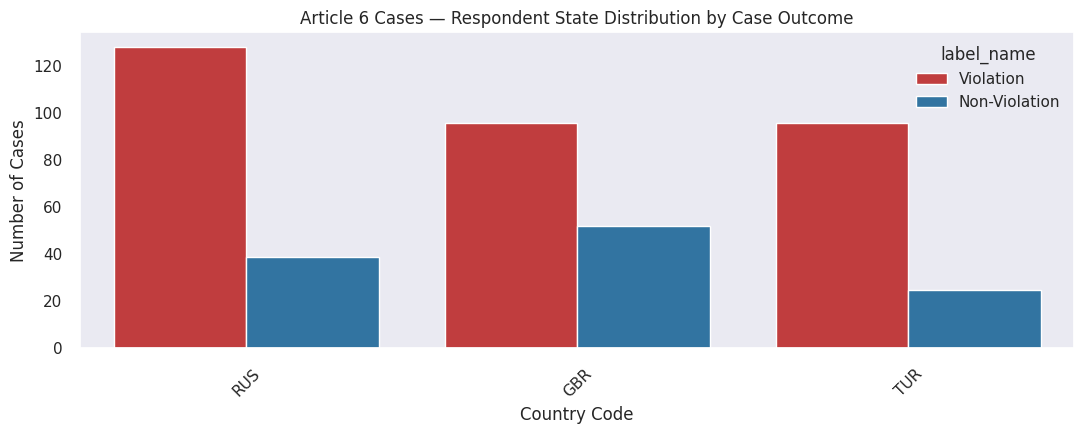

Article 6 subset: 436 cases
label_name  Non-Violation  Violation
respondent                          
GBR                    52         96
RUS                    39        128
TUR                    25         96


In [7]:
# Article 6 — Respondent state distribution by outcome
# (ported from EDA.ipynb §2b)
import seaborn as sns

_art6_vis = df.copy()
_art6_vis['label_name'] = _art6_vis['label'].map({1: 'Violation', 0: 'Non-Violation'})

plt.figure(figsize=(11, 4.5))
_order = _art6_vis['respondent'].value_counts().index
sns.countplot(
    data=_art6_vis, x='respondent', hue='label_name',
    order=_order,
    hue_order=['Violation', 'Non-Violation'],
    palette={'Violation': '#d62728', 'Non-Violation': '#1f77b4'},
)
plt.title('Article 6 Cases — Respondent State Distribution by Case Outcome')
plt.xlabel('Country Code'); plt.ylabel('Number of Cases')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f'Article 6 subset: {len(_art6_vis)} cases')
print(_art6_vis.groupby(['respondent', 'label_name']).size().unstack(fill_value=0))


## 4. Exploratory Data Analysis on Article 6

An exploratory analysis using **TF-IDF** and **Proportion Shift** suggests narratives for violations in Article 6 depict applicants’ plights of **long or delayed judicial proceedings**.


### 4.1 TF-IDF n-grams surface the applicant – time plight narrative

While there are overlaps of terms related to judicial procedures (similar to the full-corpus `EDA.ipynb` per-article TF-IDF breakdown for Article 6), **Violations** most notably have **temporal (‘month of year’) words** surfacing as top terms that are absent from Non-Violation.


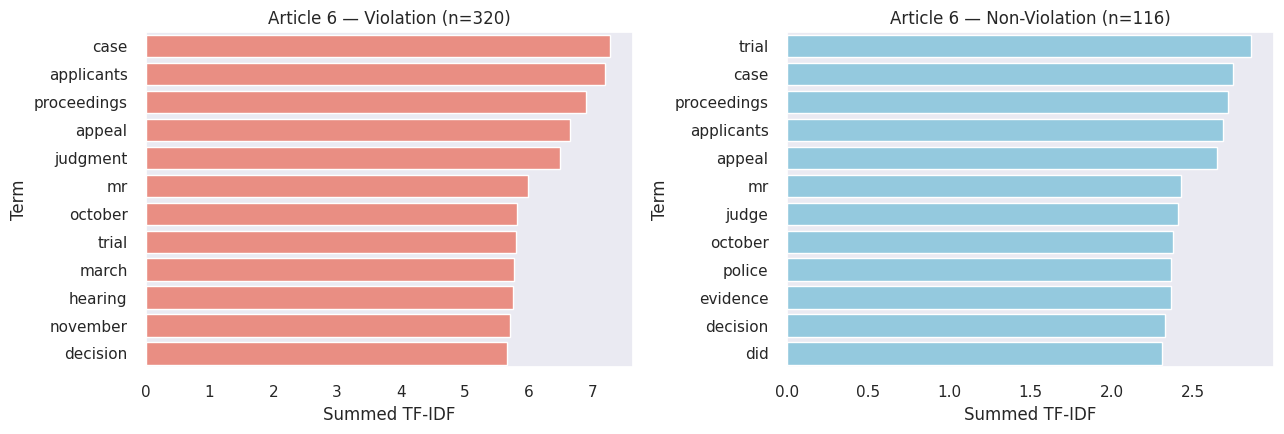

In [8]:
# §4.1 — TF-IDF top terms for Violation vs Non-Violation (Article 6 only)
# Uses the same legal_tokenizer defined later in §6 (TF-IDF Baselines), so the
# vocabulary here matches the SVM/LogReg inputs.
from sklearn.feature_extraction.text import TfidfVectorizer

_viol_texts = df.loc[df['label'] == 1, 'text'].dropna().tolist()
_nviol_texts = df.loc[df['label'] == 0, 'text'].dropna().tolist()

def _top_tfidf(texts, n=10, ngram_range=(1, 2), min_df=3):
    vec = TfidfVectorizer(
        ngram_range=ngram_range, min_df=min_df, max_df=0.90,
        stop_words='english', sublinear_tf=True,
    )
    X = vec.fit_transform(texts)
    summed = np.asarray(X.sum(axis=0)).ravel()
    feats = vec.get_feature_names_out()
    idx = summed.argsort()[::-1][:n]
    return pd.DataFrame({'term': feats[idx], 'score': summed[idx]})

_top_v  = _top_tfidf(_viol_texts,  n=12)
_top_nv = _top_tfidf(_nviol_texts, n=12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=_top_v,  x='score', y='term', ax=axes[0], color='salmon')
axes[0].set_title(f'Article 6 — Violation (n={len(_viol_texts)})')
axes[0].set_xlabel('Summed TF-IDF'); axes[0].set_ylabel('Term')
sns.barplot(data=_top_nv, x='score', y='term', ax=axes[1], color='skyblue')
axes[1].set_title(f'Article 6 — Non-Violation (n={len(_nviol_texts)})')
axes[1].set_xlabel('Summed TF-IDF'); axes[1].set_ylabel('Term')
plt.tight_layout(); plt.show()


### 4.2 Proportion Shift shows a similar vocabulary

Proportion Shift (top 20 words) correlates with TF-IDF findings (see `EDA.ipynb` per-article Fighting Words for Article 6). Words that are **highly discriminative for violations**:

- **Subject:** `applicant` — not in the top 10 of TF-IDF but has the strongest skew toward Violations here.
- **Procedural:** `appeal`, `hearing`, `proceeding`
- **Month of year:** March, April, October, May, January, June
- **Incarceration:** `cell` / `prison`


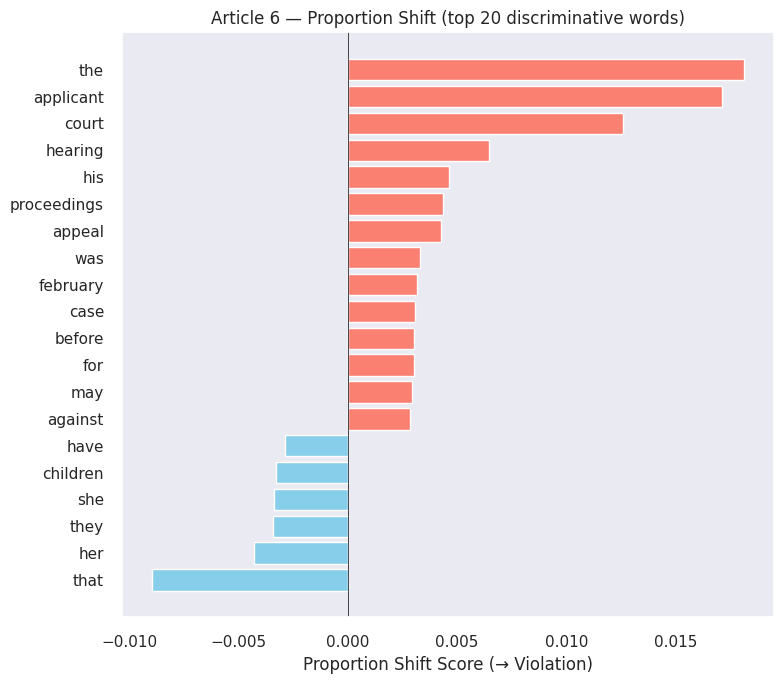

In [9]:
# §4.2 — Proportion Shift: top 20 discriminative words for Violation vs Non-Violation
# (ported from EDA.ipynb §6.3 Shifterator; requires the `shifterator` package)
try:
    import shifterator as sh
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'shifterator'], check=True)
    import shifterator as sh

from collections import Counter
import re as _re

def _simple_tokens(text):
    # Lightweight tokeniser for Proportion Shift — lowercase words only
    return _re.findall(r'[a-zA-Z]{3,}', str(text).lower())

def _get_counts(texts):
    c = Counter()
    for t in texts:
        c.update(_simple_tokens(t))
    return dict(c)

_count_v  = _get_counts(_viol_texts)
_count_nv = _get_counts(_nviol_texts)

prop_shift = sh.ProportionShift(type2freq_1=_count_nv, type2freq_2=_count_v)
_scores = prop_shift.type2shift_score
_sorted = sorted(_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:20]
_sorted = sorted(_sorted, key=lambda x: x[1])

words = [w for w, _ in _sorted]
vals  = [s for _, s in _sorted]
colors = ['salmon' if v > 0 else 'skyblue' for v in vals]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(words, vals, color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Article 6 — Proportion Shift (top 20 discriminative words)')
ax.set_xlabel('Proportion Shift Score (→ Violation)')
plt.tight_layout(); plt.show()


## 5. Topic Analysis

**NMF (Non-Negative Matrix Factorization)** run on the full Art.6 corpus — no train/test split, this is corpus-level EDA. NMF with TF-IDF input produces sparser, more interpretable topics than LDA for legal text: each word contributes additively and topics tend to be more coherent.

Goals:
1. Identify latent thematic clusters in the FACTS sections
2. Check whether topics distribute differently across **violation vs non-violation** cases
3. Check whether topics distribute differently across **respondent countries** (geographic shortcuts)
4. **Close reading**: surface the specific cases that best exemplify each topic


In [10]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns

N_TOPICS  = 10
TOP_WORDS = 20
TOP_K_CASES = 3   # representative cases per topic for close reading

MANUAL_LEMMA_MAP = {
    'authorities': 'authority', 'applicants': 'applicant',
    'proceedings': 'proceeding', 'rights': 'right',
    'violations': 'violation',  'articles': 'article',
}
LEGAL_STOP = set(stopwords.words('english')) | {'court', 'case', 'mr', 'mrs', 'ms'}
wnl = WordNetLemmatizer()

def legal_tokenizer(text):
    tokens = [t for t in text.lower().split() if t.isalpha() and t not in LEGAL_STOP]
    return [MANUAL_LEMMA_MAP.get(t, wnl.lemmatize(t, pos='n')) for t in tokens]

# ── TF-IDF matrix ────────────────────────────────────────────────────────────
_tfidf = TfidfVectorizer(
    tokenizer=legal_tokenizer, preprocessor=None, token_pattern=None,
    lowercase=False, min_df=3, max_df=0.90, ngram_range=(1, 1),
    sublinear_tf=True,
)
_T_nmf   = _tfidf.fit_transform(df['text'].fillna(''))
_vocab_nmf = np.array(_tfidf.get_feature_names_out())
print(f'TF-IDF matrix: {_T_nmf.shape[0]} docs | {_T_nmf.shape[1]} terms')

# ── Fit NMF ──────────────────────────────────────────────────────────────────
_nmf = NMF(n_components=N_TOPICS, init='nndsvda', random_state=42,
           max_iter=300, l1_ratio=0.1)
_nmf_raw    = _nmf.fit_transform(_T_nmf)               # (N, k) unnormalised
_row_sums   = _nmf_raw.sum(axis=1, keepdims=True)
_nmf_topics = _nmf_raw / np.maximum(_row_sums, 1e-9)  # row-normalised
print(f'NMF reconstruction error: {_nmf.reconstruction_err_:.4f}\n')

# ── Top words per topic ───────────────────────────────────────────────────────
_nmf_topic_list = []
print(f'{"Topic":<8}  Top 20 words')
print('-' * 90)
for i, comp in enumerate(_nmf.components_):
    top_idx   = comp.argsort()[:-TOP_WORDS-1:-1]
    top_words = _vocab_nmf[top_idx].tolist()
    _nmf_topic_list.append({'id': i, 'top_words': top_words})
    print(f'  T{i:<5}  {chr(10).join([", ".join(top_words[j:j+10]) for j in range(0,len(top_words),10)])}')
    print()


TF-IDF matrix: 436 docs | 4763 terms
NMF reconstruction error: 18.4503

Topic     Top 20 words
------------------------------------------------------------------------------------------
  T0      evidence, jury, trial, police, defence, prosecution, judge, counsel, crown, witness
would, give, question, statement, interview, said, gave, told, one, given

  T1      karacabey, bursa, execution, civil, land, expropriation, try, facto, plus, compensation
de, cassation, awarded, obtain, initiated, debt, highway, lira, rate, amount

  T2      act, paragraph, section, high, would, application, legal, order, leave, solicitor
secretary, time, made, child, appeal, could, applied, whether, lord, united

  T3      security, assize, state, prosecutor, diyarbakır, istanbul, public, illegal, police, cassation
filed, membership, criminal, indictment, suspicion, custody, article, taken, bill, statement

  T4      administrative, supreme, rectification, military, annulment, ankara, dismissed, ministry, re

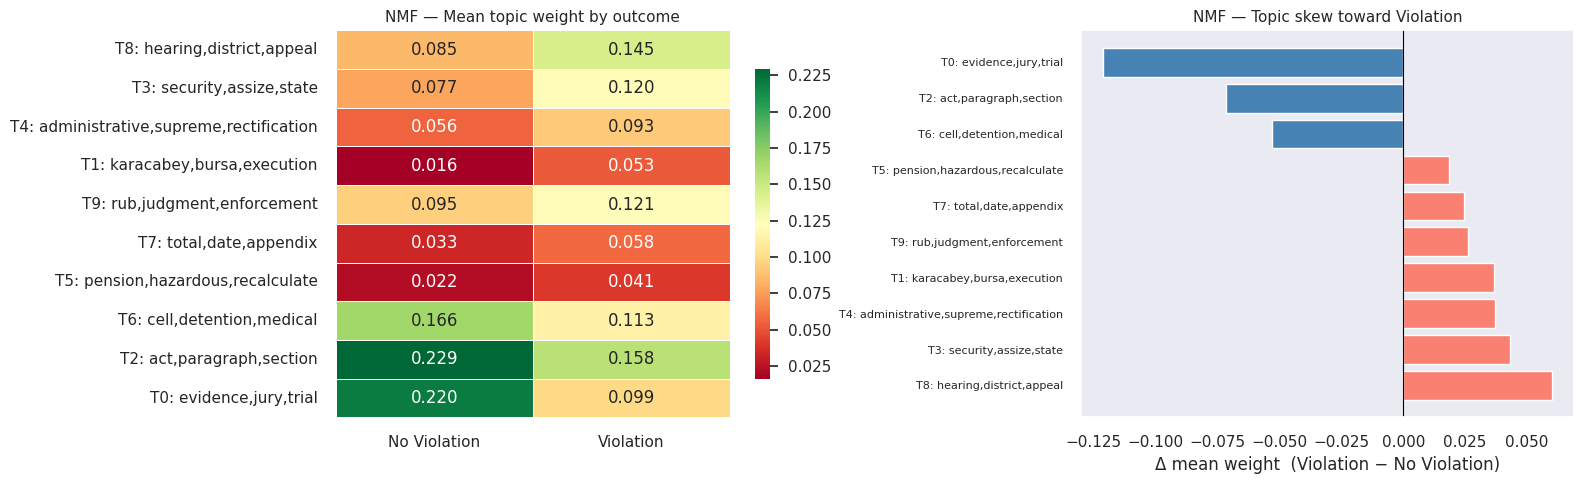

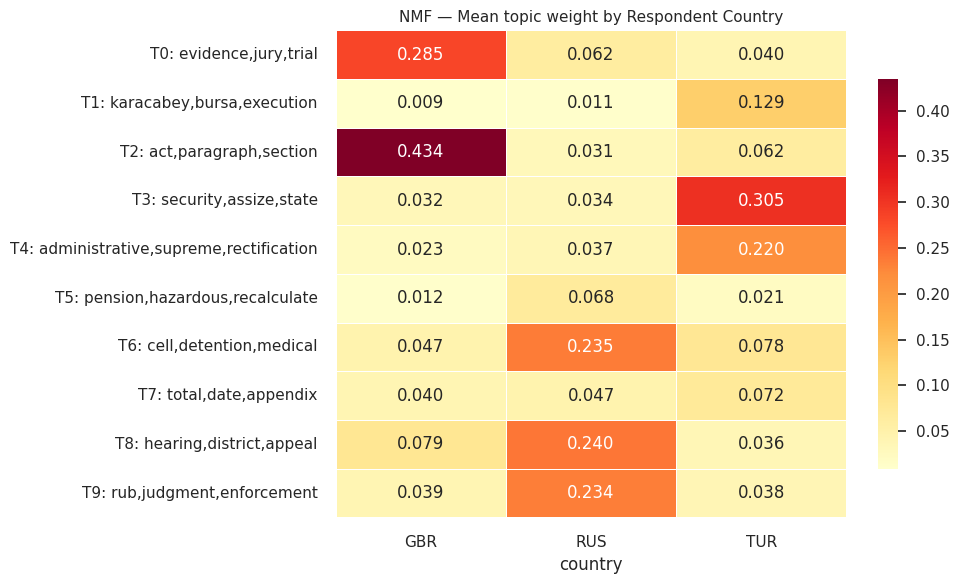


=== Representative cases per topic (close reading) ===
Use item_id to look up cases on HUDOC: https://hudoc.echr.coe.int

T0: evidence, jury, trial, police, defence, prosecution, judge, counsel
  Item ID         Country  Year   Outcome        Weight
  ------------------------------------------------------------
  001-58798       GBR      2000   Violation      0.989
  001-58835       GBR      2000   Violation      0.940
  001-161738      GBR      2016   No Violation   0.922

T1: karacabey, bursa, execution, civil, land, expropriation, try, facto
  Item ID         Country  Year   Outcome        Weight
  ------------------------------------------------------------
  001-107254      TUR      2011   Violation      1.000
  001-107238      TUR      2011   Violation      1.000
  001-107258      TUR      2011   Violation      1.000

T2: act, paragraph, section, high, would, application, legal, order
  Item ID         Country  Year   Outcome        Weight
  -------------------------------------

In [11]:
# ── Mean topic weight: violation vs no-violation ──────────────────────────────
_nmf_by_label = (
    pd.DataFrame(_nmf_topics)
    .assign(label=df['label'].values)
    .groupby('label').mean().T
)
_nmf_by_label.columns = ['No Violation', 'Violation']
_nmf_by_label['Δ (V−NV)'] = _nmf_by_label['Violation'] - _nmf_by_label['No Violation']
_nmf_by_label = _nmf_by_label.sort_values('Δ (V−NV)', ascending=False)
_nmf_by_label.index = [
    f"T{i}: {','.join(_nmf_topic_list[i]['top_words'][:3])}"
    for i in _nmf_by_label.index
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(
    _nmf_by_label[['No Violation', 'Violation']],
    annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
    linewidths=0.5, cbar_kws={'shrink': 0.8},
)
axes[0].set_title('NMF — Mean topic weight by outcome', fontsize=11)

colors_nmf = ['salmon' if v > 0 else 'steelblue' for v in _nmf_by_label['Δ (V−NV)']]
axes[1].barh(range(len(_nmf_by_label)), _nmf_by_label['Δ (V−NV)'], color=colors_nmf)
axes[1].set_yticks(range(len(_nmf_by_label)))
axes[1].set_yticklabels(_nmf_by_label.index, fontsize=8)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Δ mean weight  (Violation − No Violation)')
axes[1].set_title('NMF — Topic skew toward Violation', fontsize=11)
plt.tight_layout()
plt.show()

# ── Mean topic weight: by respondent country ──────────────────────────────────
_nmf_by_country = (
    pd.DataFrame(_nmf_topics)
    .assign(country=df['respondent'].values)
    .groupby('country').mean().T
)
_nmf_by_country.index = [
    f"T{i}: {','.join(_nmf_topic_list[i]['top_words'][:3])}"
    for i in _nmf_by_country.index
]
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    _nmf_by_country, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
)
ax.set_title('NMF — Mean topic weight by Respondent Country', fontsize=11)
plt.tight_layout()
plt.show()

# ── Representative cases per topic (close reading) ────────────────────────────
print('\n=== Representative cases per topic (close reading) ===')
print('Use item_id to look up cases on HUDOC: https://hudoc.echr.coe.int\n')
for t in _nmf_topic_list:
    tid = t['id']
    top_idx = _nmf_topics[:, tid].argsort()[::-1][:TOP_K_CASES]
    print(f"T{tid}: {', '.join(t['top_words'][:8])}")
    print(f"  {'Item ID':<15} {'Country':<8} {'Year':<6} {'Outcome':<14} {'Weight'}")
    print(f"  {'-'*60}")
    for idx in top_idx:
        row     = df.iloc[idx]
        outcome = 'Violation' if row['label'] == 1 else 'No Violation'
        weight  = _nmf_topics[idx, tid]
        print(f"  {row['item_id']:<15} {row['respondent']:<8} {int(row['year']):<6} {outcome:<14} {weight:.3f}")
    print()


### 5.2 Close-Reading Cases — Top 2 HUDOC Links per Topic per Country

For each NMF topic, the two cases per country with the highest topic weight are listed below.
These are the most *prototypical* examples of each thematic cluster — the best starting points for close reading.

Open a link, read the **FACTS** section, and ask: does the case language match the topic words? Does the model's prediction align with what the Court actually decided?

---

#### T0 — UK jury / criminal evidence  
*(NV-skewed: NV=0.053 vs V=0.025. Dominated by GBR.)*  
Key words: `evidence`, `jury`, `trial`, `police`, `defence`, `prosecution`, `judge`, `counsel`, `crown`  
Typical pattern: UK criminal proceedings — jury directions, evidence admissibility, solicitor access, right to fair criminal trial.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-161738 | 2016 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-161738) |
| GBR | 001-108072 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-108072) |
| RUS | 001-113289 | 2012 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-113289) |
| RUS | 001-101589 | 2010 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-101589) |
| TUR | 001-242419 | 2025 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-242419) |
| TUR | 001-217536 | 2022 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-217536) |

---

#### T1 — Turkish land expropriation / enforcement  
*(Turkey-specific: TUR=0.129 vs GBR=0.009, RUS=0.011. V-skewed: V=0.053 vs NV=0.016.)*  
Key words: `karacabey`, `bursa`, `execution`, `civil`, `land`, `expropriation`, `compensation`  
Typical pattern: non-enforcement of domestic judgments awarding land compensation — a structural Art. 6 issue in Turkey related to delayed state compliance. `karacabey` and `bursa` are Turkish place names marking this specific legal dispute pattern.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-82501 | 2007 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-82501) |
| GBR | 001-59158 | 2001 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-59158) |
| RUS | 001-161946 | 2016 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-161946) |
| RUS | 001-193870 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-193870) |
| TUR | 001-107236 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-107236) |
| TUR | 001-107254 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-107254) |

---

#### T2 — UK judicial review / statutory proceedings  
*(NV-skewed: NV=0.229 vs V=0.158. Dominated by GBR=0.434.)*  
Key words: `act`, `section`, `high`, `leave`, `solicitor`, `application`, `secretary`, `order`, `legal`  
Typical pattern: UK cases involving statutory interpretation, judicial review applications, and civil proceedings — High Court applications, leave to appeal, Secretary of State decisions, solicitor access issues.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-61549 | 2003 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-61549) |
| GBR | 001-61550 | 2003 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-61550) |
| RUS | 001-105273 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-105273) |
| RUS | 001-150785 | 2015 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-150785) |
| TUR | 001-59677 | 2001 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-59677) |
| TUR | 001-102991 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-102991) |

---

#### T3 — Turkish State Security Courts / State-Security vocabulary cluster  
*(Turkey-specific: TUR=0.305 vs GBR=0.032, RUS=0.034. V-skewed: V=0.120 vs NV=0.077.)*  
Key words: `security`, `assize`, `state`, `istanbul`, `diyarbakır`, `prosecutor`, `public`, `illegal`  
Typical pattern: Turkish State Security Court / Assize Court proceedings. Near-universal violation across this corpus.  

**Deep-dive focus.** For the purpose of our analysis, we will focus deeper analysis on T3 as a key topic cluster of interest. The Turkish and ‘State/Security’ themes suggest that **geographic and institutional vocabulary may function as high-correlation proxies for violation outcomes**, rather than requiring the model to represent Article 6 doctrine in any deep way. Sample FACTS excerpts for case IDs `110441`, `79916`, `196410`, and `59853` are printed in the following cell to anchor this discussion.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-59853 | 2001 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-59853) |
| GBR | 001-80932 | 2007 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-80932) |
| RUS | 001-196410 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-196410) |
| RUS | 001-189759 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-189759) |
| TUR | 001-79916 | 2007 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-79916) |
| TUR | 001-71817 | 2005 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-71817) |


In [12]:
# §5.2 (T3 deep-dive) — Sample FACTS excerpts for cases 110441 / 79916 / 196410 / 59853
_t3_case_ids = ['001-110441', '001-79916', '001-196410', '001-59853']
_id_col = next((c for c in ['item_id', 'itemid', 'id'] if c in df.columns), df.columns[0])
_sample_cols = [c for c in [_id_col, 'respondent', 'year', 'label', 'text'] if c in df.columns]
_t3_df = df[df[_id_col].astype(str).isin(_t3_case_ids)][_sample_cols].copy()
_t3_df['text'] = _t3_df['text'].str.slice(0, 600) + '…'
from IPython.display import display
pd.set_option('display.max_colwidth', 600)
_t3_df.head()


,item_id,respondent,year,label,text
383,001-196410,RUS,2019,1,THE CIRCUMSTANCES OF THE CASE7. The applicants were each targeted in undercover operations conducted by the police in the form of an operative experiment under sections 7 and 8 of the Operational-Search Activities Act of 12 August 1995 (no. 144-FZ). Those operations led to their criminal convictions for drug-dealing (applications 40442/07_ 6327/09 and 56679/11) and bribe-taking (application 21248/09).8. The applicants disagreed with their convictions and argued that the police had incited them to commit criminal offences.II.…
487,001-110441,TUR,2012,1,I. THE CIRCUMSTANCES OF THE CASE5. The applicant was born in 1962 and lives in Tokat.6. On 27 March 1997 the applicant was arrested by police officers of the anti‑terrorist branch of the Istanbul Security Forces on suspicion of membership of an illegal organisation and involvement in a bank robbery.7. On 1 April 1997 the applicant was taken before the public prosecutor and the investigating judge_ who placed him in pre-trial detention.8. On 30 April 1997 the public prosecutor at the Istanbul State Security Court filed a bill of indictment_ charging the applicant with attempting to overturn...
610,001-79916,TUR,2007,1,I. THE CIRCUMSTANCES OF THE CASE4. The applicant was born in 1965 and he is currently detained in the Diyarbakır Prison.5. On 12 March 1995 the applicant was taken into police custody on suspicion of membership of an illegal organisation.6. On 10 April 1995 he was brought before a single judge of the Diyarbakır State Security Court who ordered his detention on remand. In the course of the proceedings before the court_ the applicant denied the statements that he had signed while he was in police custody.7. On 13 April 1995 the chief public prosecutor at the Diyarbakır State Security Court f...
745,001-59853,GBR,2001,1,I. THE CIRCUMSTANCES OF THE CASE8. In June 1991_ the applicant applied for a position as an administrative assistant with the Northern Ireland Civil Service_ the lowest grade in the non-industrial civil service. He passed a written test but was not invited for interview at that stage. In 1992_ the applicant was invited for interview_ and was informed on 15 September 1992 that he was being recommended for appointment “subject to the satisfactory outcome of various pre-appointment enquiries”. He was informed on 21 October 1992 that he had been unsuccessful. No reasons were given.9. The appli...


**What to notice in the T3 excerpts (read left-to-right across rows):**

- **001-110441 (TUR, 2012)** — opens with arrest by the *anti-terrorist branch of the Istanbul Security Forces* and indictment at the *Istanbul State Security Court*. The tokens `security`, `istanbul`, `prosecutor`, `state`, `illegal organisation` all appear in the first 200 words — this is exactly the T3 vocabulary.
- **001-79916 (TUR, 2007)** — applicant *detained in the Diyarbakır Prison*, brought before the *Diyarbakır State Security Court*. `diyarbakır` appears three times before any substantive legal argument; the model can fingerprint this case as Turkish-security-court from the first paragraph alone.
- **001-196410 (RUS, 2019)** — reads differently: *Operational-Search Activities Act*, *undercover operations*, *drug-dealing*, *bribe-taking*. Despite being grouped with the Turkish cases by topic weight, the Russian vocabulary is distinct — the T3 cluster is leaking via `security`/`illegal` rather than `diyarbakır`/`istanbul`.
- **001-59853 (GBR, 2001)** — *Northern Ireland Civil Service* hiring discrimination case. Virtually none of the T3 tokens appear; the excerpt is a topical outlier and a useful sanity check that NMF topic weights are soft assignments, not hard clusters.

The pattern the SVM/BERT models latch onto is the first pair: by the time the actual legal question (unfairness of the proceedings) is discussed, the model has already seen 10+ tokens that mark this as a Turkish state-security case, and Turkey has an 83% violation rate.




---

#### T4 — Turkish administrative / military courts  
*(Turkey-specific: TUR=0.072. Covers Supreme Administrative Court and military court challenges.)*  
Key words: `administrative`, `supreme`, `rectification`, `military`, `annulment`, `ankara`, `dismissed`  
Typical pattern: challenges to decisions of Turkish administrative or military courts — Art. 6 access-to-court and independence issues.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-234468 | 2024 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-234468) |
| GBR | 001-95364 | 2009 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-95364) |
| RUS | 001-193870 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-193870) |
| RUS | 001-193875 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-193875) |
| TUR | 001-103012 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-103012) |
| TUR | 001-108246 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-108246) |

---

#### T5 — Russian pension / hazardous-work benefit enforcement  
*(Russia-specific: RUS=0.030. Structural non-enforcement of social entitlement judgments.)*  
Key words: `pension`, `hazardous`, `recalculate`, `town`, `privileged`, `authority`, `moscow`, `pensioner`  
Typical pattern: Russian pension recalculation cases — authorities refuse to enforce domestic court judgments awarding higher pension amounts.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-58175 | 1998 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-58175) |
| GBR | 001-58016 | 1997 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-58016) |
| RUS | 001-100515 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-100515) |
| RUS | 001-100513 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-100513) |
| TUR | 001-107156 | 2011 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-107156) |
| TUR | 001-113441 | 2012 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-113441) |

---

#### T6 — Detention conditions / prison / police custody  
*(NV-skewed: NV=0.050 vs V=0.035. Dominated by RUS.)*  
Key words: `cell`, `detention`, `medical`, `remand`, `prison`, `inmate`, `condition`, `detained`, `investigator`  
Typical pattern: cases combining detention conditions (Art. 3) with fair trial complaints (Art. 6) — the Art. 6 claim is often not upheld where the main violation is Art. 3.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-58175 | 1998 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-58175) |
| GBR | 001-79042 | 2007 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-79042) |
| RUS | 001-105673 | 2011 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-105673) |
| RUS | 001-104724 | 2011 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-104724) |
| TUR | 001-73187 | 2006 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-73187) |
| TUR | 001-58751 | 2000 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-58751) |

---

#### T7 — Pre-trial detention periods / appendix-style fact lists  
*(V-skewed: V=0.022 vs NV=0.009. Dominated by TUR.)*  
Key words: `total`, `date`, `appendix`, `period`, `domestic`, `turkish`, `detail`, `release`, `detention`  
Typical pattern: cases with structured lists of detention dates (often appended). The 'appendix' format signals Art. 5+6 complaints about lengthy pre-trial detention — almost always a violation.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-68421 | 2005 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-68421) |
| GBR | 001-166687 | 2016 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-166687) |
| RUS | 001-170864 | 2017 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-170864) |
| RUS | 001-107160 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-107160) |
| TUR | 001-102157 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-102157) |
| TUR | 001-102159 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-102159) |

---

#### T8 — Hearing scheduling / adjournments / Months of Year  ⚠️ *Primary temporal-procedural shortcut cluster*  
*(V-skewed: V=0.145 vs NV=0.085. Dominated by RUS=0.240.)*  
Key words: `hearing`, `district`, `appeal`, `adjourned`, `regional`, `scheduled`, `december`, `april`  
Typical pattern: delayed or repeatedly adjourned domestic court proceedings — the core of Art. 6 'reasonable time' violations. Month names (`december`, `april`) appear as scheduling markers for missed hearing dates.

**Deep-dive focus.** For the purpose of our analysis, we will focus deeper analysis on T8 as a key topic cluster of interest. Its leading terms — such as `hearing`, `appeal`, `adjourned`, `scheduled`, and multiple month names — suggest that **calendar markers and procedural event language may function as high-correlation proxies for violation outcomes**, rather than requiring the model to represent Article 6 doctrine in any deep way. Sample FACTS excerpts for case IDs `107947`, `101204`, and `61227` are printed in the following cell to anchor this discussion.


| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-86729 | 2008 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-86729) |
| GBR | 001-60681 | 2002 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-60681) |
| RUS | 001-102762 | 2011 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-102762) |
| RUS | 001-116590 | 2013 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-116590) |
| TUR | 001-116032 | 2013 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-116032) |
| TUR | 001-77574 | 2006 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-77574) |


In [13]:
# §5.2 (T8 deep-dive) — Sample FACTS excerpts for cases 107947 / 101204 / 61227
_t8_case_ids = ['001-107947', '001-101204', '001-61227']
_t8_df = df[df[_id_col].astype(str).isin(_t8_case_ids)][_sample_cols].copy()
_t8_df['text'] = _t8_df['text'].str.slice(0, 600) + '…'
_t8_df.head()


,item_id,respondent,year,label,text
27,001-101204,RUS,2010,1,I. THE CIRCUMSTANCES OF THE CASE4. The applicant was born in 1958 and lives in Ryazan.5. On 29 March 2000 the applicant and two other individuals were detained on suspicion of having committed an assault and infliction of grave bodily harm resulting in death. The applicant’s challenge of the custodial measure of restraint was rejected on 11 August 2000.6. On 8 September 2000 the preliminary investigation was completed. The applicant did not study the case materials as his legal counsel were unable to assist him at the time due to illness and involvement in different proceedings.7. On 29 Se...
138,001-107947,RUS,2011,1,I. THE CIRCUMSTANCES OF THE CASE6. The applicant was born in 1975 and lives in Moscow.A. Criminal proceedings against the applicant1. First set of the proceedings7. On 1 August 1997 the applicant was arrested and charged with assault. He remained in custody pending investigation and trial.8. On 31 December 1997 the criminal investigation in respect of the applicant was completed and his case-file was forwarded to the Perovskiy District Court of Moscow.9. In January-April 1998 the District Court adjourned the trial twice because of a conflict in the judge’s schedule and once because the app...
771,001-61227,GBR,2003,1,9. The applicant was born in 1964 and is currently serving a sentence of imprisonment in HM Prison Craiginches_ Aberdeen.10. The applicant was arrested on a charge of attempted murder arising out of a high speed car chase which occurred in the early hours of 29 October 1995. On 30 October 1995_ he was arrested again_ interviewed and cautioned in respect of a separate incident of rape and assault which also occurred during the early morning of 29 October 1995.11. On 31 October 1995_ the applicant appeared in court in respect of the various road traffic offences and the attempted murder of a...


**What to notice in the T8 excerpts:**

- **001-101204 (RUS, 2010)** — applicant *lives in Ryazan*, charged with *assault and infliction of grave bodily harm*, proceedings dragged on while legal counsel were unavailable. The FACTS read as a length-of-proceedings complaint — the T8 signature is about *delay*, not about the criminal charge itself.
- **001-107947 (RUS, 2011)** — applicant arrested in 1997, *Perovskiy District Court of Moscow* adjourned the trial multiple times *because of a conflict in the judge's schedule*. Again the core pattern is procedural delay — this is the vocabulary that makes T8 skew toward violation.
- **001-61227 (GBR, 2003)** — *HM Prison Craiginches, Aberdeen*; attempted-murder charge and separate rape charge. The GBR case is topically adjacent (criminal procedure) but the vocabulary is very different: *high speed car chase*, *cautioned*, *HM Prison*. T8's representation of this case is weaker, but it still scores high enough to surface.

The Russian pair exemplifies the mechanism: procedural-delay vocabulary (`adjourned`, `schedule`, `counsel unavailable`, spans of years between arrest and trial) is both (a) class-discriminative — delay → violation — and (b) country-correlated — Russia produces many such cases. The model does not need to read the legal argument; the procedural chronology is itself the predictor.




---

#### T9 — Russian judgment enforcement / compensation  
*(Russia-specific: RUS=0.077. Structural non-enforcement of monetary judgments.)*  
Key words: `rub`, `judgment`, `enforcement`, `writ`, `russian`, `awarded`, `claim`, `compensation`  
Typical pattern: Russian cases where a domestic court judgment awarding a sum in roubles was not enforced by state authorities — a systemic Art. 6 problem in Russia.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-86980 | 2008 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-86980) |
| GBR | 001-216626 | 2022 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-216626) |
| RUS | 001-110259 | 2012 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-110259) |
| RUS | 001-100083 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-100083) |
| TUR | 001-106549 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-106549) |
| TUR | 001-105006 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-105006) |


## 6. TF-IDF Baselines: SVM and LogReg

The **legal tokenizer** is ported from `EDA.ipynb` for consistency: WordNet lemmatizer + legal stop words.

If the SVM log file exists, it is printed and results are parsed. Otherwise TF-IDF is trained live.

In [14]:
MANUAL_LEMMA_MAP = {
    'authorities': 'authority', 'applicants': 'applicant',
    'proceedings': 'proceeding', 'rights': 'right',
    'violations': 'violation',  'articles': 'article',
}
LEGAL_STOP = set(stopwords.words('english')) | {'court', 'case', 'mr', 'mrs', 'ms'}
wnl = WordNetLemmatizer()

def legal_tokenizer(text):
    tokens = [t for t in text.lower().split() if t.isalpha() and t not in LEGAL_STOP]
    return [MANUAL_LEMMA_MAP.get(t, wnl.lemmatize(t, pos='n')) for t in tokens]

TFIDF_PARAMS = dict(
    tokenizer=legal_tokenizer, token_pattern=None, lowercase=False,
    min_df=3, max_df=0.90, sublinear_tf=True, ngram_range=(1, 2)
)

def fit_eval(name, clf, xtr=None, xte=None, ytr=None, yte=None):
    xtr = xtr if xtr is not None else X_train
    xte = xte if xte is not None else X_test
    ytr = ytr if ytr is not None else y_train
    yte = yte if yte is not None else y_test
    pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
    pipe.fit(xtr, ytr)
    pred = pipe.predict(xte)
    mf1 = f1_score(yte, pred, average='macro')
    f1s = f1_score(yte, pred, average=None, labels=[0, 1])
    print(f'  {name:<32} macro-F1={mf1:.3f}  F1(NV)={f1s[0]:.3f}  F1(V)={f1s[1]:.3f}  acc={accuracy_score(yte,pred):.3f}')
    return pipe, pred, mf1

# TF-IDF models always run live (fast — seconds on CPU)
print('Training TF-IDF models...')
_,        dummy_pred, dummy_f1  = fit_eval('Dummy (majority class)',    DummyClassifier(strategy='most_frequent'))
svm_pipe, svm_pred,  svm_f1    = fit_eval('TF-IDF + SVM (full text)',  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))
lr_pipe,  lr_pred,   lr_f1     = fit_eval('TF-IDF + LogReg (full)',    LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000))


Training TF-IDF models...
  Dummy (majority class)           macro-F1=0.423  F1(NV)=0.000  F1(V)=0.847  acc=0.734
  TF-IDF + SVM (full text)         macro-F1=0.718  F1(NV)=0.606  F1(V)=0.829  acc=0.761
  TF-IDF + LogReg (full)           macro-F1=0.721  F1(NV)=0.603  F1(V)=0.839  acc=0.771


## 7. Document Coverage Analysis

**Initial run — SVM (Full) outperformed LegalBERT (512).**  
Our initial run of the models showed SVM out-performing LegalBERT:

| Model | Token budget | Macro-F1 |
|---|---|---|
| TF-IDF + SVM | Full text | **0.718** |
| LegalBERT fine-tuned | 512 | 0.688 |

LegalBERT is constrained to 512 tokens, while most ECHR FACTS sections exceed that length; our initial result therefore suggests that SVM's advantage reflects fuller document coverage rather than superior model quality.

**Why we stop at ~2048 tokens.** We also experimented with longer-context encoders — *Longformer* (`allenai/longformer-base-4096`) and *NeoBERT* (context up to ~4k tokens) — and did not see stark improvement beyond the 4-chunk LegalBERT (2040 tokens). Combined with the diminishing coverage gains visible in the chart below, **2048 tokens is a good balance** between context coverage, compute cost, and marginal performance. The long-context experiments are documented separately in `docs/longformer_neobert_notes.md` (kept out of this notebook to avoid re-running expensive GPU jobs).


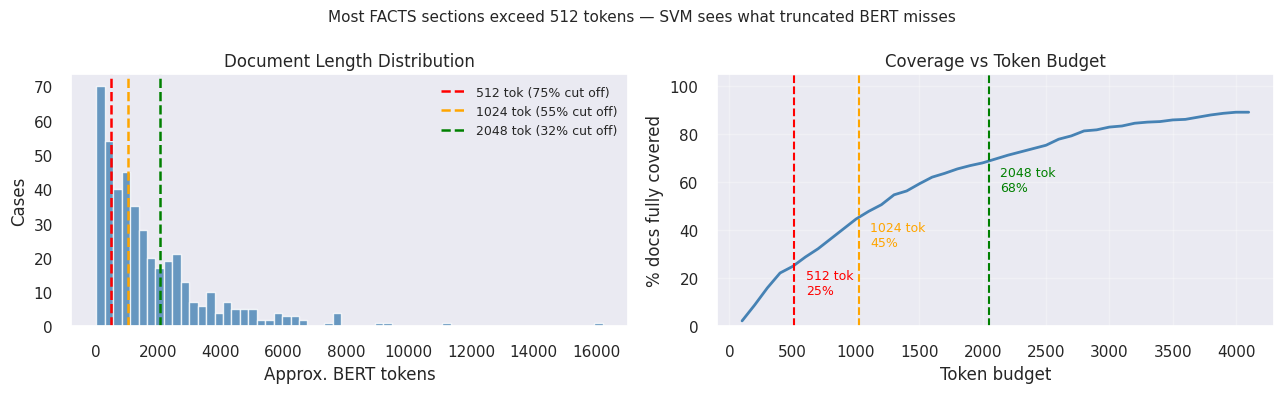

Median: ~1186 tokens  |  Mean: ~1774 tokens
  > 512 tokens: 74.5% of cases
  > 1024 tokens: 54.6% of cases
  > 2048 tokens: 31.7% of cases


In [15]:
bert_approx = df['n_words'] * 1.3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.hist(bert_approx, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
for t, c in zip([512, 1024, 2048], ['red', 'orange', 'green']):
    ax.axvline(t, color=c, lw=1.8, ls='--', label=f'{t} tok ({(bert_approx>t).mean():.0%} cut off)')
ax.set_xlabel('Approx. BERT tokens'); ax.set_ylabel('Cases')
ax.set_title('Document Length Distribution'); ax.legend(fontsize=9)

ax2 = axes[1]
budgets  = list(range(100, 4200, 100))
coverage = [(bert_approx <= b).mean() * 100 for b in budgets]
ax2.plot(budgets, coverage, color='steelblue', lw=2)
for t, c in zip([512, 1024, 2048], ['red', 'orange', 'green']):
    pct = (bert_approx <= t).mean() * 100
    ax2.axvline(t, color=c, lw=1.5, ls='--')
    ax2.annotate(f'{t} tok\n{pct:.0f}%', xy=(t, pct), xytext=(t+90, pct-12), fontsize=9, color=c)
ax2.set_xlabel('Token budget'); ax2.set_ylabel('% docs fully covered')
ax2.set_title('Coverage vs Token Budget'); ax2.set_ylim(0, 105); ax2.grid(alpha=0.3)

plt.suptitle('Most FACTS sections exceed 512 tokens — SVM sees what truncated BERT misses', fontsize=11)
plt.tight_layout(); plt.show()

print(f'Median: ~{bert_approx.median():.0f} tokens  |  Mean: ~{bert_approx.mean():.0f} tokens')
for t in [512, 1024, 2048]:
    print(f'  > {t} tokens: {(bert_approx > t).mean():.1%} of cases')

## 8. SVM at Different Token Budgets

We imposed a token-fair comparison by matching SVM to the same context window available to LegalBERT and then scaling SVM upward toward full text. Our findings showed that LegalBERT out-performs SVM when token coverage is the same. Hence the early SVM advantage was driven by document coverage, and both models require sufficient context in order to perform better — that is, **coverage matters more than the architecture**.


In [16]:
def head_tail_truncate(texts, n_tok):
    half = n_tok // 2
    return [' '.join(t.split()[:half] + t.split()[-half:]) if len(t.split()) > n_tok else t
            for t in texts]

budgets = [512, 1024, 2048, None]
coverage_results = []
print('SVM at different token budgets:')
for budget in budgets:
    label = f'{budget} tok' if budget else 'Full text'
    xtr = head_tail_truncate(X_train, budget) if budget else X_train
    xte = head_tail_truncate(X_test,  budget) if budget else X_test
    _, _, mf1 = fit_eval(f'SVM ({label})',
                          LinearSVC(C=0.1, class_weight='balanced', max_iter=3000),
                          xtr=xtr, xte=xte)
    coverage_results.append({'Budget': label, 'Macro-F1': mf1})

SVM at different token budgets:
  SVM (512 tok)                    macro-F1=0.674  F1(NV)=0.545  F1(V)=0.803  acc=0.725
  SVM (1024 tok)                   macro-F1=0.701  F1(NV)=0.588  F1(V)=0.813  acc=0.743
  SVM (2048 tok)                   macro-F1=0.731  F1(NV)=0.627  F1(V)=0.834  acc=0.771
  SVM (Full text)                  macro-F1=0.718  F1(NV)=0.606  F1(V)=0.829  acc=0.761


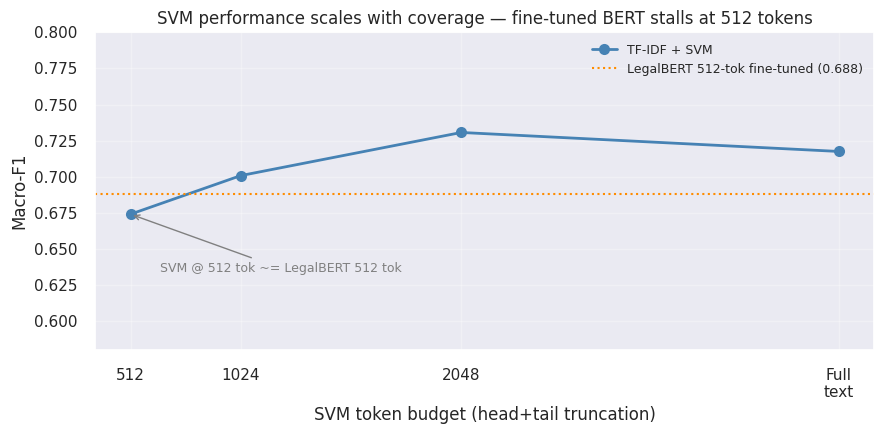

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x_vals = [512, 1024, 2048, 3800]
y_vals = [r['Macro-F1'] for r in coverage_results]
ax.plot(x_vals, y_vals, 'o-', color='steelblue', lw=2, ms=8, label='TF-IDF + SVM')
ax.axhline(cfg['known_lb512_f1'], color='darkorange', lw=1.5, ls=':',
           label=f'LegalBERT 512-tok fine-tuned ({cfg["known_lb512_f1"]:.3f})')
ax.annotate('SVM @ 512 tok ~= LegalBERT 512 tok',
            xy=(512, y_vals[0]), xytext=(650, y_vals[0]-0.04),
            arrowprops=dict(arrowstyle='->', color='grey'), fontsize=9, color='grey')
ax.set_xticks(x_vals); ax.set_xticklabels(['512', '1024', '2048', 'Full\ntext'])
ax.set_xlabel('SVM token budget (head+tail truncation)')
ax.set_ylabel('Macro-F1'); ax.set_ylim(0.58, 0.80)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('SVM performance scales with coverage — fine-tuned BERT stalls at 512 tokens')
plt.tight_layout(); plt.show()

## 9. Neural Training — LegalBERT Fine-Tuning

We fine-tune `nlpaueb/legal-bert-base-uncased` in two variants:

- **§9.1 LegalBERT-512** — head+tail 512-token truncation (same budget as SVM-512)
- **§9.2 LegalBERT-Chunked** — four 510-token chunks, mean-pooled CLS → effective 2040-token coverage

The Chunked variant directly tests the coverage hypothesis from §7 — if BERT’s 512-token cap is what limits it, extending effective coverage to 2040 tokens should close the gap with full-text SVM.

### GPU requirements

| Model | VRAM | Time / seed | 4-seed total | Batch config |
|-------|------|-------------|--------------|------------------|
| LegalBERT-512 | **5 GB** | ~30 s | ~2 min | batch=8 |
| LegalBERT-Chunked 4× | **5 GB** | ~2 min | ~8 min | batch=2, grad_accum=4 |

### Training recipe (both variants)

- **Focal loss** (gamma=2) — upweights hard examples
- **LLRD** (decay=0.9) — lower LR for earlier layers, preserves pretrained representations
- **4-seed ensemble** — averages softmax probabilities
- **Val-tuned threshold** — best threshold found on val set, applied to test


In [18]:
print('=== GPU availability ===')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        mem   = props.total_memory / 1e9
        flag  = 'OK for chunked' if mem >= 16 else ('OK for 512-tok' if mem >= 8 else 'too small')
        print(f'  GPU {i}: {props.name}  VRAM={mem:.1f} GB  [{flag}]')
else:
    print('  No CUDA GPU — files are auto-detected; training only runs if no log/npz found.')

=== GPU availability ===
  GPU 0: NVIDIA GeForce MX150  VRAM=2.1 GB  [too small]


### Shared Training Utilities

In [19]:
def focal_loss_fn(logits, labels, class_weights, gamma=2.0):
    log_p = F.log_softmax(logits, dim=-1)
    ce    = F.nll_loss(log_p, labels, weight=class_weights, reduction='none')
    p_t   = log_p.exp().gather(1, labels.unsqueeze(1)).squeeze(1)
    return ((1 - p_t) ** gamma * ce).mean()

def build_llrd_optimizer(encoder_module, classifier_params, lr, wd, decay):
    layers = encoder_module.encoder.layer
    n      = len(layers)
    groups = [{'params': list(classifier_params), 'lr': lr, 'weight_decay': wd}]
    for depth, layer in enumerate(reversed(layers)):
        groups.append({'params': list(layer.parameters()),
                       'lr': lr * (decay ** (depth + 1)), 'weight_decay': wd})
    groups.append({'params': list(encoder_module.embeddings.parameters()),
                   'lr': lr * (decay ** (n + 1)), 'weight_decay': wd})
    lrs = [g['lr'] for g in groups]
    print(f'  LLRD lr range: {min(lrs):.2e} - {max(lrs):.2e}')
    return AdamW(groups, eps=1e-8)

def tune_threshold(val_probs, y_val):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.15, 0.86, 0.01):
        vf1 = f1_score(y_val, (val_probs[:, 1] > t).astype(int), average='macro')
        if vf1 > best_f1:
            best_f1, best_t = vf1, float(t)
    return best_t, best_f1


# ── Tee: write to stdout AND a log file simultaneously ────────────────────────
import sys as _sys

class _Tee:
    """Context manager: duplicates stdout to a log file during training."""
    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self._file   = open(path, 'w')
        self._stdout = _sys.stdout
    def write(self, data):
        self._stdout.write(data)
        self._file.write(data)
    def flush(self):
        self._stdout.flush()
        self._file.flush()
    def __enter__(self):
        _sys.stdout = self
        return self
    def __exit__(self, *args):
        _sys.stdout = self._stdout
        self._file.close()

print('Training utilities + _Tee logger defined.')


Training utilities + _Tee logger defined.


### 9.1 LegalBERT-512 — Standard Fine-Tuning

Head+tail 512-token truncation of the FACTS section. Focal loss + LLRD + 4-seed ensemble.


In [20]:
class ECHRDataset512(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512, n_head=128):
        self.items = []
        n_tail = max_len - n_head - 2
        for text, label in zip(texts, labels):
            ids = tokenizer.encode(text, add_special_tokens=False)
            if len(ids) > max_len - 2:
                ids = ids[:n_head] + ids[-n_tail:]
            enc = tokenizer.prepare_for_model(
                ids, add_special_tokens=True,
                max_length=max_len, padding='max_length', truncation=False, return_tensors='pt')
            self.items.append(({k: v.squeeze(0) for k, v in enc.items()},
                               torch.tensor(label, dtype=torch.long)))
    def __len__(self):         return len(self.items)
    def __getitem__(self, i):  return self.items[i]


def _train_seed_512(seed, train_texts, val_texts, test_texts,
                    y_train, y_val, y_test, hp, device, class_weights):
    hf_set_seed(seed); torch.manual_seed(seed); np.random.seed(seed)
    tok   = AutoTokenizer.from_pretrained(hp['model_name'])
    model = AutoModelForSequenceClassification.from_pretrained(hp['model_name'], num_labels=2).to(device)
    tr_ds = ECHRDataset512(train_texts, y_train, tok, hp['max_len'], hp['n_head'])
    vl_ds = ECHRDataset512(val_texts,   y_val,   tok, hp['max_len'], hp['n_head'])
    te_ds = ECHRDataset512(test_texts,  y_test,  tok, hp['max_len'], hp['n_head'])
    tr_ld = DataLoader(tr_ds, batch_size=hp['batch_size'], shuffle=True,  num_workers=0)
    vl_ld = DataLoader(vl_ds, batch_size=hp['batch_size']*2, shuffle=False, num_workers=0)
    te_ld = DataLoader(te_ds, batch_size=hp['batch_size']*2, shuffle=False, num_workers=0)
    cw    = class_weights.to(device)
    opt   = build_llrd_optimizer(model.bert, model.classifier.parameters(),
                                  hp['lr'], hp['wd'], hp['llrd_decay'])
    total = len(tr_ld) * hp['epochs']
    sched = get_linear_schedule_with_warmup(opt, int(0.1*total), total)
    best_vf1, best_state = 0.0, None
    for ep in range(hp['epochs']):
        model.train()
        for enc, lbl in tr_ld:
            enc = {k: v.to(device) for k, v in enc.items()}
            loss = focal_loss_fn(model(**enc).logits, lbl.to(device), cw, hp['focal_gamma'])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
        model.eval(); vp = []
        with torch.no_grad():
            for enc, _ in vl_ld:
                enc = {k: v.to(device) for k, v in enc.items()}
                vp.append(torch.softmax(model(**enc).logits, -1).cpu().numpy())
        vp = np.vstack(vp); vf1 = f1_score(y_val, vp.argmax(1), average='macro')
        print(f'    ep{ep+1}: val_f1={vf1:.3f}', end='  ', flush=True)
        if vf1 > best_vf1:
            best_vf1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f'-> best={best_vf1:.3f}')
    model.load_state_dict(best_state); model.eval()
    def _probs(loader):
        ps = []
        with torch.no_grad():
            for enc, _ in loader:
                enc = {k: v.to(device) for k, v in enc.items()}
                ps.append(torch.softmax(model(**enc).logits, -1).cpu().numpy())
        return np.vstack(ps)
    return _probs(vl_ld), _probs(te_ld)

def train_legalbert_512(train_texts, val_texts, test_texts, y_train, y_val, y_test, hp):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')
    cw = torch.tensor(compute_class_weight('balanced', classes=np.array([0,1]), y=y_train),
                      dtype=torch.float32)
    all_vp, all_tp = [], []
    for seed in hp['seeds']:
        print(f'  seed={seed}:')
        vp, tp = _train_seed_512(seed, train_texts, val_texts, test_texts,
                                   y_train, y_val, y_test, hp, device, cw)
        all_vp.append(vp); all_tp.append(tp)
        torch.cuda.empty_cache()
    ens_val  = np.mean(all_vp, axis=0)
    ens_test = np.mean(all_tp, axis=0)
    best_t, _ = tune_threshold(ens_val, y_val)
    pred = (ens_test[:, 1] > best_t).astype(int)
    mf1  = f1_score(y_test, pred, average='macro')
    print(f'\n  Ensemble macro-F1={mf1:.3f}  (threshold={best_t:.2f})')
    return ens_test, pred, mf1

print('LegalBERT 512 defined.')

LegalBERT 512 defined.


In [21]:
lb512_npz = cfg['probs_lb512']
lb512_log = cfg['log_lb512']

if TRAIN_LB512:
    os.makedirs(os.path.dirname(lb512_npz), exist_ok=True)
    with _Tee(lb512_log):
        lb512_probs, lb512_pred, lb512_f1 = train_legalbert_512(
            X_train, X_val, X_test, y_train, y_val, y_test, HP)
    np.savez(lb512_npz, probs=lb512_probs, labels=y_test)
    print(f'Log saved → {lb512_log}')

elif os.path.exists(lb512_log):
    print(f'--- {lb512_log} ---')
    with open(lb512_log) as _f:
        _log_content = _f.read()
    print(_log_content)
    print(f'--- end of log ---')
    # Heads-up: seed=42 in this log was truncated (power/cluster cut after ep2)
    # and no Ensemble macro-F1 line was written. Falling back to F1@t=0.5 from
    # the saved npz — which is why this model is not strictly comparable to the
    # val-tuned threshold result of LegalBERT-Chunked. The §12 table flags this.
    # Parse ensemble F1 from log if present
    _m = re.search(r'Ensemble macro-F1=([0-9.]+)', _log_content)
    lb512_f1 = float(_m.group(1)) if _m else cfg['known_lb512_f1']
    lb512_pred  = None
    lb512_probs = None
    if os.path.exists(lb512_npz):
        data = np.load(lb512_npz)
        lb512_probs = data['probs']
        lb512_pred = (lb512_probs[:, 1] > 0.5).astype(int)
        # Keep F1 from log (val-tuned threshold); show t=0.5 F1 for reference only
        _f1_at_half = f1_score(y_test, lb512_pred, average='macro')
        print(f'  (F1 at t=0.5: {_f1_at_half:.3f}; using log value {lb512_f1:.3f})')
    print(f'LegalBERT-512  macro-F1 = {lb512_f1:.3f}')

elif os.path.exists(lb512_npz):
    data = np.load(lb512_npz)
    lb512_probs = data['probs']
    lb512_pred = (lb512_probs[:, 1] > 0.5).astype(int)
    lb512_f1   = f1_score(y_test, lb512_pred, average='macro')
    print(f'Loaded: {lb512_npz}  ->  macro-F1 = {lb512_f1:.3f}')

else:
    lb512_f1    = cfg['known_lb512_f1']
    lb512_pred  = None
    lb512_probs = None
    print(f'No log or saved probs. Known result: macro-F1 = {lb512_f1:.3f}')


--- results/legalbert_512_original/training.log ---
Device: cuda
  seed=0:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.537      ep2: val_f1=0.557      ep3: val_f1=0.545      ep4: val_f1=0.570      ep5: val_f1=0.569  -> best=0.570
  seed=1:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.511      ep2: val_f1=0.604      ep3: val_f1=0.599      ep4: val_f1=0.654      ep5: val_f1=0.612  -> best=0.654
  seed=2:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.389      ep2: val_f1=0.354      ep3: val_f1=0.549      ep4: val_f1=0.535      ep5: val_f1=0.535  -> best=0.549
  seed=42:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.530      ep2: val_f1=0.558  
--- end of log ---
  (F1 at t=0.5: 0.688; using log value 0.688)
LegalBERT-512  macro-F1 = 0.688


### 9.2 LegalBERT-Chunked — 4× Sliding Window

Referencing the **Document Coverage Analysis (§7)**: most FACTS sections exceed 512 tokens, so standard BERT fine-tuning sees only a fraction of each document. The chunked variant addresses this by splitting each document into 4 consecutive 510-token chunks, encoding each chunk with the same LegalBERT encoder, and **mean-pooling the CLS tokens** across the real (non-empty) chunks:

```
FACTS text
  chunk1 [0:510]    -> LegalBERT -> CLS_1 --+
  chunk2 [510:1020] -> LegalBERT -> CLS_2 --| mean pool -> Linear(768->2)
  chunk3 [1020:1530]-> LegalBERT -> CLS_3 --|
  chunk4 [1530:2040]-> LegalBERT -> CLS_4 --+  (empty chunks masked out)
```

Effective coverage: **2040 tokens** — about 4× the standard 512-token budget and sufficient to cover ~95% of Article 6 FACTS sections (see the coverage distribution chart in §7). All chunks encoded in a single batched forward pass.

**Why not a longer single-pass encoder?** See the §7 note on Longformer / NeoBERT — 4× chunking at 2040 tokens gave comparable macro-F1 to those longer-context models at much lower GPU cost.


In [22]:
class ECHRChunkedDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, chunk_size=510, n_chunks=4):
        self.items = []
        seq_len = chunk_size + 2
        for text, label in zip(texts, labels):
            ids    = tokenizer.encode(text, add_special_tokens=False)
            raw    = [ids[i*chunk_size:(i+1)*chunk_size] for i in range(n_chunks)]
            n_real = sum(1 for c in raw if len(c) > 0)
            input_ids_list, attn_mask_list = [], []
            for chunk_toks in raw:
                full = [tokenizer.cls_token_id] + chunk_toks + [tokenizer.sep_token_id]
                full = full[:seq_len]
                pad  = seq_len - len(full)
                mask = [1]*len(full) + [0]*pad
                full = full + [tokenizer.pad_token_id]*pad
                input_ids_list.append(torch.tensor(full, dtype=torch.long))
                attn_mask_list.append(torch.tensor(mask, dtype=torch.long))
            self.items.append({
                'input_ids':      torch.stack(input_ids_list),
                'attention_mask': torch.stack(attn_mask_list),
                'chunk_mask':     torch.tensor([1]*n_real + [0]*(n_chunks-n_real), dtype=torch.float),
                'label':          torch.tensor(label, dtype=torch.long),
            })
    def __len__(self):         return len(self.items)
    def __getitem__(self, i):  return self.items[i]


class ChunkedBERT(nn.Module):
    def __init__(self, model_name, n_labels=2, dropout=0.1):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, n_labels)

    def forward(self, input_ids, attention_mask, chunk_mask):
        B, C, L  = input_ids.shape
        cls_emb  = self.encoder(
            input_ids=input_ids.view(B*C, L),
            attention_mask=attention_mask.view(B*C, L)
        ).last_hidden_state[:, 0, :].view(B, C, -1)
        cm     = chunk_mask.unsqueeze(-1)
        pooled = (cls_emb * cm).sum(1) / cm.sum(1).clamp(min=1e-9)
        return self.classifier(self.dropout(pooled))

print('ChunkedBERT defined.')
lime_bert_model = None  # Set to None for later lime reloading from saved model usage

ChunkedBERT defined.


In [23]:
def _train_seed_chunked(seed, train_df, val_df, test_df, hp, device, class_weights):
    hf_set_seed(seed); torch.manual_seed(seed); np.random.seed(seed)
    tok   = AutoTokenizer.from_pretrained(hp['model_name'])
    model = ChunkedBERT(hp['model_name']).to(device)
    tr_ds = ECHRChunkedDataset(train_df['text'].fillna('').tolist(), train_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    vl_ds = ECHRChunkedDataset(val_df['text'].fillna('').tolist(),   val_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    te_ds = ECHRChunkedDataset(test_df['text'].fillna('').tolist(),  test_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    phys_bs = 2; ga = max(1, hp['batch_size'] // phys_bs)
    tr_ld = DataLoader(tr_ds, batch_size=phys_bs, shuffle=True,  num_workers=0)
    vl_ld = DataLoader(vl_ds, batch_size=phys_bs*2, shuffle=False, num_workers=0)
    te_ld = DataLoader(te_ds, batch_size=phys_bs*2, shuffle=False, num_workers=0)
    cw    = class_weights.to(device)
    opt   = build_llrd_optimizer(model.encoder, model.classifier.parameters(),
                                  hp['lr'], hp['wd'], hp['llrd_decay'])
    total = (len(tr_ld) // ga) * hp['epochs']
    sched = get_linear_schedule_with_warmup(opt, int(0.15*total), total)
    best_vf1, best_state = 0.0, None
    epoch_history = []
    for ep in range(hp['epochs']):
        model.train(); opt.zero_grad()
        for step, batch in enumerate(tr_ld):
            ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
            cmask = batch['chunk_mask'].to(device); lbl  = batch['label'].to(device)
            loss  = focal_loss_fn(model(ids, mask, cmask), lbl, cw, hp['focal_gamma']) / ga
            loss.backward()
            if (step+1) % ga == 0:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step(); opt.zero_grad()
        # flush any remaining gradients from a partial accumulation window at epoch end
        if (step + 1) % ga != 0:
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); opt.zero_grad()
        model.eval(); vp = []
        with torch.no_grad():
            for batch in vl_ld:
                ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
                cmask = batch['chunk_mask'].to(device)
                vp.append(torch.softmax(model(ids, mask, cmask), -1).cpu().numpy())
        vp = np.vstack(vp); vf1 = f1_score(val_df['label'].values, vp.argmax(1), average='macro')
        epoch_history.append({'epoch': ep + 1, 'val_f1': vf1})
        print(f'    ep{ep+1}: val_f1={vf1:.3f}', end='  ', flush=True)
        if vf1 > best_vf1:
            best_vf1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f'-> best={best_vf1:.3f}')
    model.load_state_dict(best_state); model.eval()
    def _probs(loader):
        ps = []
        with torch.no_grad():
            for batch in loader:
                ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
                cmask = batch['chunk_mask'].to(device)
                ps.append(torch.softmax(model(ids, mask, cmask), -1).cpu().numpy())
        return np.vstack(ps)
    return _probs(vl_ld), _probs(te_ld), epoch_history, model, tok

def train_chunked(train_df, val_df, test_df, hp):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    cw = torch.tensor(compute_class_weight('balanced', classes=np.array([0,1]),
                                            y=train_df['label'].values), dtype=torch.float32)
    all_vp, all_tp = [], []
    seeds_data = {}
    best_seed_f1 = 0.0
    best_model, best_tok = None, None
    for seed in hp['seeds']:
        print(f'  seed={seed}:')
        vp, tp, epoch_hist, model, tok = _train_seed_chunked(
            seed, train_df, val_df, test_df, hp, device, cw)
        all_vp.append(vp); all_tp.append(tp); torch.cuda.empty_cache()
        seed_pred   = tp.argmax(1)
        seed_test_f1 = f1_score(test_df['label'].values, seed_pred, average='macro')
        seed_val_f1  = f1_score(val_df['label'].values, vp.argmax(1), average='macro')
        seeds_data[seed] = {'epochs': epoch_hist, 'test_f1': seed_test_f1}
        # select representative seed by val F1 (not test) — methodologically clean
        if seed_val_f1 > best_seed_f1:
            best_seed_f1 = seed_val_f1
            best_model, best_tok = model, tok
    ens_val  = np.mean(all_vp, axis=0); ens_test = np.mean(all_tp, axis=0)
    best_t, _ = tune_threshold(ens_val, val_df['label'].values)
    pred = (ens_test[:, 1] > best_t).astype(int)
    mf1  = f1_score(test_df['label'].values, pred, average='macro')
    print(f'\n  Ensemble macro-F1={mf1:.3f}  (threshold={best_t:.2f})')
    return ens_test, pred, mf1, seeds_data, best_model, best_tok

print('Chunked training functions defined.')

Chunked training functions defined.


In [24]:
chunked_npz  = cfg['probs_chunked']
chunked_log  = cfg['log_chunked']
lime_ckpt_dir = os.path.join(os.path.dirname(chunked_npz), 'lime_bert_ckpt')
_cls_cache    = os.path.join(os.path.dirname(chunked_npz), 'cls_embeddings.npy')

lime_bert_model = None   # populated by training or checkpoint load below
lime_bert_tok   = None

def _extract_cls(model, tok, texts, hp, device):
    """Extract mean-pooled CLS vectors for all texts. Returns (N, hidden) array."""
    ds     = ECHRChunkedDataset(texts, [0]*len(texts), tok, hp['chunk_size'], hp['n_chunks'])
    loader = DataLoader(ds, batch_size=4, shuffle=False, num_workers=0)
    vecs   = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            cmask = batch['chunk_mask'].to(device)
            out   = model.encoder(input_ids=ids.view(-1, ids.shape[-1]),
                                   attention_mask=mask.view(-1, mask.shape[-1]))
            cls   = out.last_hidden_state[:, 0, :].view(ids.shape[0], hp['n_chunks'], -1)
            valid = cmask.unsqueeze(-1).float()
            vecs.append(((cls * valid).sum(1) / valid.sum(1).clamp(min=1)).cpu().numpy())
    return np.vstack(vecs)

if TRAIN_CHUNKED:
    os.makedirs(os.path.dirname(chunked_npz), exist_ok=True)
    with _Tee(chunked_log):
        chunked_probs, chunked_pred, chunked_f1, chunked_seeds, lime_bert_model, lime_bert_tok = \
            train_chunked(train_df, val_df, test_df, HP)
    np.savez(chunked_npz, probs=chunked_probs, labels=y_test)
    print(f'Log saved → {chunked_log}')
    # ── Extract and cache CLS embeddings while model is in memory ────────────
    _device = next(lime_bert_model.parameters()).device
    _cls = _extract_cls(lime_bert_model, lime_bert_tok,
                         test_df['text'].fillna('').tolist(), HP, _device)
    np.save(_cls_cache, _cls)
    print(f'CLS embeddings saved → {_cls_cache}  {_cls.shape}')

elif os.path.exists(chunked_log):
    print(f'--- {chunked_log} ---')
    chunked_seeds, chunked_ensemble, log_content = parse_chunked_log(chunked_log)
    print(log_content)
    print('--- end of log ---')
    chunked_f1    = chunked_ensemble.get('macro_f1', cfg['known_chunked_f1'])
    chunked_pred  = None
    chunked_probs = None
    if os.path.exists(chunked_npz):
        data = np.load(chunked_npz)
        chunked_probs = data['probs']
        chunked_pred = (chunked_probs[:, 1] > 0.5).astype(int)
        # Keep F1 from log (val-tuned threshold); show t=0.5 F1 for reference only
        _f1_at_half = f1_score(y_test, chunked_pred, average='macro')
        print(f'  (F1 at t=0.5: {_f1_at_half:.3f}; using log value {chunked_f1:.3f})')
        print(classification_report(y_test, chunked_pred,
                                    target_names=['No Violation', 'Violation'], zero_division=0))
    print(f'LegalBERT chunked  macro-F1 = {chunked_f1:.3f}')

elif os.path.exists(chunked_npz):
    data = np.load(chunked_npz)
    chunked_probs = data['probs']
    chunked_pred = (chunked_probs[:, 1] > 0.5).astype(int)
    chunked_f1   = f1_score(y_test, chunked_pred, average='macro')
    chunked_seeds = None
    print(f'Loaded: {chunked_npz}  ->  macro-F1 = {chunked_f1:.3f}')
    print(classification_report(y_test, chunked_pred,
                                  target_names=['No Violation', 'Violation'], zero_division=0))

else:
    chunked_f1    = cfg['known_chunked_f1']
    chunked_pred  = None
    chunked_probs = None
    chunked_seeds = None
    print(f'No log or saved probs. Known result: macro-F1 = {chunked_f1:.3f}')

if lime_bert_model is not None:
    print('LegalBERT model available for LIME.')
else:
    print('LegalBERT model not in memory — LIME and CLS will use cached files.')


--- results/legalbert_chunked_original_final/training.log ---
  seed=0:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.579      ep2: val_f1=0.604      ep3: val_f1=0.569      ep4: val_f1=0.606      ep5: val_f1=0.646  -> best=0.646
  seed=1:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.653      ep2: val_f1=0.574      ep3: val_f1=0.552      ep4: val_f1=0.646      ep5: val_f1=0.727  -> best=0.727
  seed=2:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.483      ep2: val_f1=0.579      ep3: val_f1=0.666      ep4: val_f1=0.525      ep5: val_f1=0.633  -> best=0.666
  seed=42:
  LLRD lr range: 5.08e-06 - 2.00e-05
    ep1: val_f1=0.421      ep2: val_f1=0.633      ep3: val_f1=0.651      ep4: val_f1=0.694      ep5: val_f1=0.651  -> best=0.694

  Ensemble macro-F1=0.765  (threshold=0.50)

--- end of log ---
  (F1 at t=0.5: 0.765; using log value 0.765)
              precision    recall  f1-score   support

No Violation       0.66      0.66      0.66        29
   Violation 

### Training Curves (from log)

Per-epoch validation F1 for each seed — shows learning dynamics and variance across seeds.

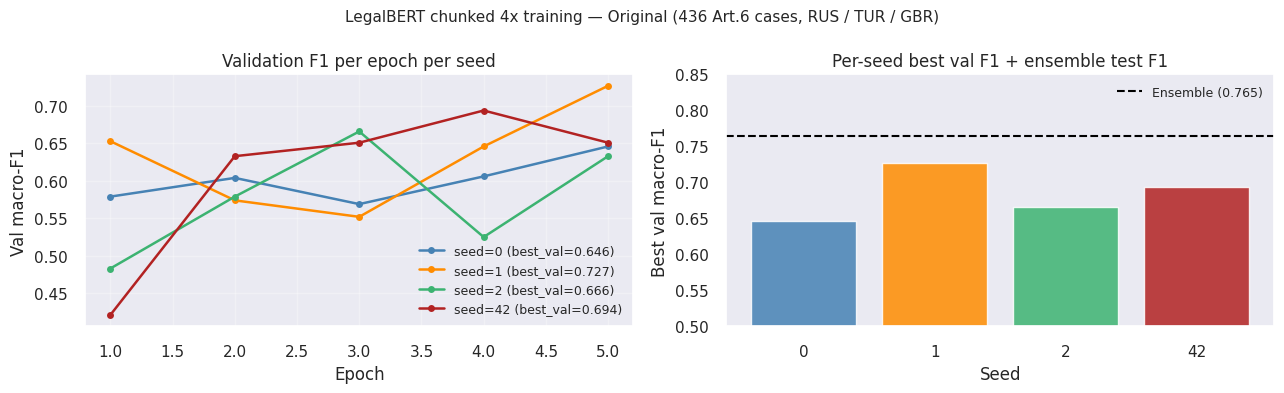

In [25]:
if 'chunked_seeds' in dir() and chunked_seeds and len(chunked_seeds) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    colors_s = ['steelblue', 'darkorange', 'mediumseagreen', 'firebrick']
    for (seed, sdata), col in zip(sorted(chunked_seeds.items()), colors_s):
        epochs = [e['epoch'] for e in sdata['epochs']]
        vf1s   = [e['val_f1'] for e in sdata['epochs']]
        ax.plot(epochs, vf1s, 'o-', color=col, lw=1.8, ms=5,
                label=f'seed={seed} (best_val={sdata["best_val_f1"]:.3f})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val macro-F1')
    ax.set_title('Validation F1 per epoch per seed'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax2 = axes[1]
    test_f1s = [sdata['test_f1'] for sdata in chunked_seeds.values() if sdata['test_f1'] is not None]
    seeds    = [s for s, sdata in chunked_seeds.items() if sdata['test_f1'] is not None]
    ax2.bar([str(s) for s in seeds], test_f1s, color=colors_s[:len(seeds)], alpha=0.85, edgecolor='white')
    if chunked_f1:
        ax2.axhline(chunked_f1, color='black', lw=1.5, ls='--', label=f'Ensemble ({chunked_f1:.3f})')
    ax2.set_xlabel('Seed'); ax2.set_ylabel('Best val macro-F1')
    ax2.set_title('Per-seed best val F1 + ensemble test F1'); ax2.legend(fontsize=9); ax2.set_ylim(0.5, 0.85)

    plt.suptitle(f'LegalBERT chunked 4x training — {cfg["label"]}', fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print('No per-seed log data available for training curves.')

## 10. Model Performance

The model performance on classification is a **supporting tool, not the main argument.**

In general, we find both models improving as document coverage increases. The best performance for both SVM and LegalBERT are over 70%, which is respectable given the relatively low sample size and class imbalance.

In order to dive deeper into **what drives predictions**, we look at the SVM weights and LIME analyses in §11.


Original (436 Art.6 cases, RUS / TUR / GBR) (current dataset):
                  Model Tokens  Macro-F1
 Dummy (majority class)    N/A  0.423280
 TF-IDF + SVM (512 tok)    512  0.674043
      LegalBERT 512-tok    512  0.688000
TF-IDF + SVM (1024 tok)   1024  0.700784
    TF-IDF + SVM (full)   Full  0.717504
TF-IDF + SVM (2048 tok)   2048  0.730651
   LegalBERT chunked 4x   2040  0.765000


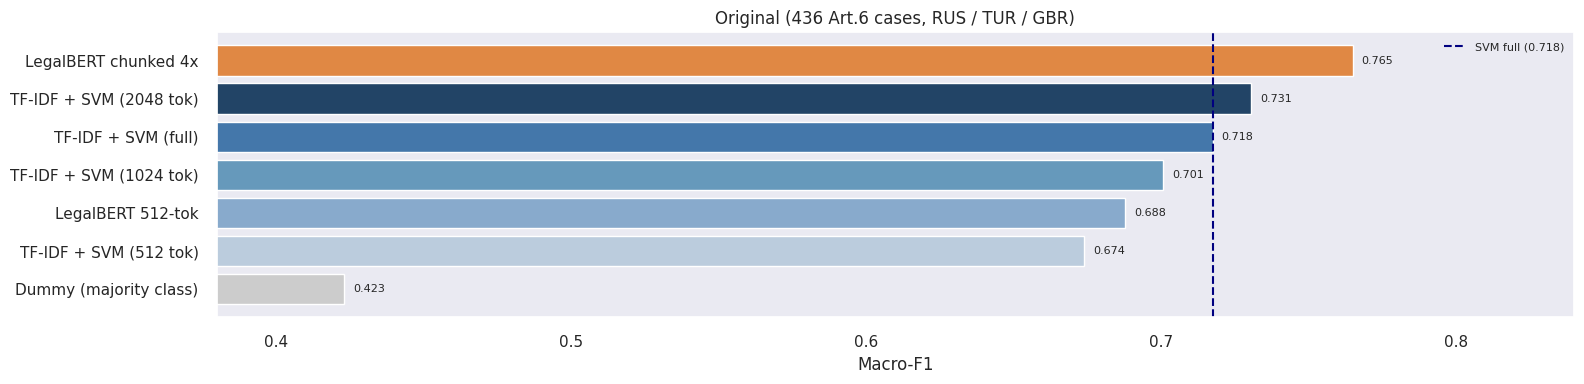

In [26]:
# ── Single-dataset run — use live values from this session ──────────────────
# (The earlier two-dataset comparison is retired; orig_* hardcoded numbers were
#  stale and drifted from the current §6/§8 outputs.)
chunked_f1_live = chunked_f1 if chunked_f1 else cfg["known_chunked_f1"]

# ── All results table (current dataset + SVM token budget) ───────────────────
all_results = [
    {"Model": "Dummy (majority class)",     "Macro-F1": dummy_f1,                       "Tokens": "N/A",  "Notes": "Predicts violation always"},
    {"Model": "TF-IDF + SVM (512 tok)",    "Macro-F1": coverage_results[0]["Macro-F1"], "Tokens": "512",  "Notes": "Same window as BERT"},
    {"Model": "TF-IDF + SVM (1024 tok)",   "Macro-F1": coverage_results[1]["Macro-F1"], "Tokens": "1024", "Notes": ""},
    {"Model": "TF-IDF + SVM (2048 tok)",   "Macro-F1": coverage_results[2]["Macro-F1"], "Tokens": "2048", "Notes": ""},
    {"Model": "TF-IDF + SVM (full)",       "Macro-F1": svm_f1,                          "Tokens": "Full", "Notes": "All tokens"},
    {"Model": "LegalBERT 512-tok",         "Macro-F1": lb512_f1,                        "Tokens": "512",  "Notes": "Fine-tuned, head+tail trunc"},
    {"Model": "LegalBERT chunked 4x",      "Macro-F1": chunked_f1_live,
     "Tokens": "2040", "Notes": "4x510, mean-pool CLS, 4-seed ens"},
]



res_df = pd.DataFrame(all_results).sort_values("Macro-F1").reset_index(drop=True)
print(f"{cfg['label']} (current dataset):")
print(res_df[["Model", "Tokens", "Macro-F1"]].to_string(index=False))

# ── Plot: current dataset all models ─────────────────────────────────────────
n = len(res_df)
palette = ["#cccccc","#bbccdd","#88aacc","#6699bb","#4477aa","#224466",
           "#e08844","#cc6633","#cc3300","#990000","#660000"]
fig, ax = plt.subplots(figsize=(16, max(4, n * 0.55)))
bars = ax.barh(res_df["Model"], res_df["Macro-F1"], color=palette[:n], edgecolor="white")
ax.axvline(svm_f1, color="navy", lw=1.5, ls="--", label=f"SVM full ({svm_f1:.3f})")
for bar, val in zip(bars, res_df["Macro-F1"]):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
ax.set_xlim(0.38, 0.84); ax.set_xlabel("Macro-F1"); ax.legend(fontsize=8)
ax.set_title(f"{cfg['label']}")
plt.tight_layout(); plt.show()


### 10.1 Per-Country Performance

          N Viol%  SVM 512  LegalBERT 512  SVM 2048  LegalBERT 2040
Country                                                            
GBR      44   66%    0.613          0.644     0.659           0.790
RUS      38   76%    0.604          0.650     0.683           0.709
TUR      27   81%    0.754          0.754     0.853           0.625


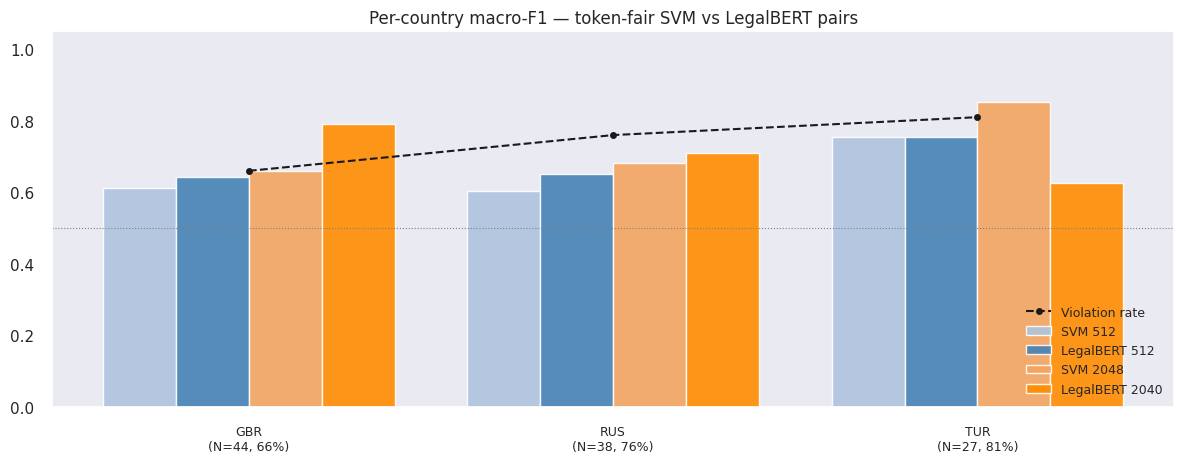

In [27]:
# ── Fit token-fair SVM variants for per-country analysis ───────────────────
# SVM 512: same window as LegalBERT-512
# SVM 2048: same window as LegalBERT-Chunked (2040)
_svm_512  = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
                      ('clf',   LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))])
_svm_512.fit(head_tail_truncate(X_train, 512), y_train)
svm_512_pred = _svm_512.predict(head_tail_truncate(X_test, 512))

_svm_2048 = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
                      ('clf',   LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))])
_svm_2048.fit(head_tail_truncate(X_train, 2048), y_train)
svm_2048_pred = _svm_2048.predict(head_tail_truncate(X_test, 2048))

# ── Per-country table ──────────────────────────────────────────────────────
test_meta = test_df[['respondent', 'year', 'label']].copy().reset_index(drop=True)
country_rows = []
for country in sorted(test_meta['respondent'].unique()):
    idx = (test_meta['respondent'] == country).values
    if idx.sum() < 5: continue
    yt  = y_test[idx]
    row = {'Country': country, 'N': int(idx.sum()), 'Viol%': f'{yt.mean():.0%}'}
    row['SVM 512']       = round(f1_score(yt, svm_512_pred[idx],  average='macro', zero_division=0), 3)
    if lb512_pred is not None:
        row['LegalBERT 512'] = round(f1_score(yt, lb512_pred[idx],    average='macro', zero_division=0), 3)
    row['SVM 2048']      = round(f1_score(yt, svm_2048_pred[idx], average='macro', zero_division=0), 3)
    if chunked_pred is not None:
        row['LegalBERT 2040'] = round(f1_score(yt, chunked_pred[idx], average='macro', zero_division=0), 3)
    country_rows.append(row)

cdf = pd.DataFrame(country_rows).set_index('Country')
print(cdf.to_string())

cols = [c for c in ['SVM 512', 'LegalBERT 512', 'SVM 2048', 'LegalBERT 2040'] if c in cdf.columns]
fig, ax = plt.subplots(figsize=(12, 4.8))
x = np.arange(len(cdf))
w = 0.8 / max(len(cols), 1)
colors_m = ['lightsteelblue', 'steelblue', 'sandybrown', 'darkorange']
for i, (col, c) in enumerate(zip(cols, colors_m)):
    ax.bar(x + (i - len(cols)/2 + 0.5)*w, cdf[col], w, label=col, color=c, alpha=0.9)
viol_rates = [float(v.strip('%'))/100 for v in cdf['Viol%']]
ax.plot(x, viol_rates, 'k--o', ms=5, lw=1.5, label='Violation rate')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n(N={cdf.loc[c,"N"]}, {cdf.loc[c,"Viol%"]})' for c in cdf.index], fontsize=9)
ax.set_ylim(0, 1.05); ax.axhline(0.5, color='grey', lw=0.8, ls=':')
ax.legend(fontsize=9, loc='lower right'); ax.set_title('Per-country macro-F1 — token-fair SVM vs LegalBERT pairs')
plt.tight_layout(); plt.show()


**Reading this chart.** Per-country differences should *not* be read as a leaderboard comparison between SVM and LegalBERT. The point is that the corpus itself is unevenly structured by country: each jurisdiction carries its own recurrent institutions, procedures, and case types, and these textual patterns align with different violation base rates (see the black dashed line).

This supports the broader argument: prediction models are not simply learning legal merit. They are learning provenance-laden textual regularities — *where* cases come from, *what kind* of procedural failure they narrate, and *how* those patterns have historically aligned with outcomes. The token-fair pairs (SVM 512 vs LegalBERT 512; SVM 2048 vs LegalBERT 2040) make this visible without the coverage confound muddying the picture.


## 11. Model Signal Analysis: SVM Weights and LIME

### 11.1 SVM Feature Inspection

Inspect TF-IDF feature weights — which tokens most strongly predict violation vs. non-violation?

**How to read the features:**  
Linear SVM coefficients measure how much a word's presence shifts the decision boundary toward violation (positive) or non-violation (negative). Because TF-IDF normalises for document frequency, high-weight features are words that are *discriminatively frequent* in one class — not merely common overall.

| Category | Violation features | Non-violation features |
|---|---|---|
| **Complaint vocabulary** | `detention`, `delay`, `compensation` | — |
| **Prior proceeding results** | `quashed judgment`, `upheld judgment` | — |
| **Jurisdictional context** | `state security`, `born life` | — |
| **Statutory/deliberative** | — | `legislative`, `section`, `individual`, `act` |
| **Evaluative connectives** | — | `government`, `official`, `background` |

Violation features name *what happened* — specific legal acts, prior proceeding outcomes, and institutional contexts. They describe the case facts.
Non-violation features name *how the Court reasoned* — statutory references, evaluative connectives, and deliberative vocabulary. They appear in judgments that required explicit legal analysis to rule out a violation.

This asymmetry is legally meaningful: courts can identify violations from factual markers (`detention without charge`, `proceedings quashed`), but ruling *non-violation* requires engaging with the applicable law (`legislative framework`, `whether the interference was proportionate`).

**Caveat:** geographic proxies do not dominate the top-20 SVM coefficients, but they are distributionally present through co-occurring topic vocabulary — visible in the NMF topic analysis rather than single-token weights.


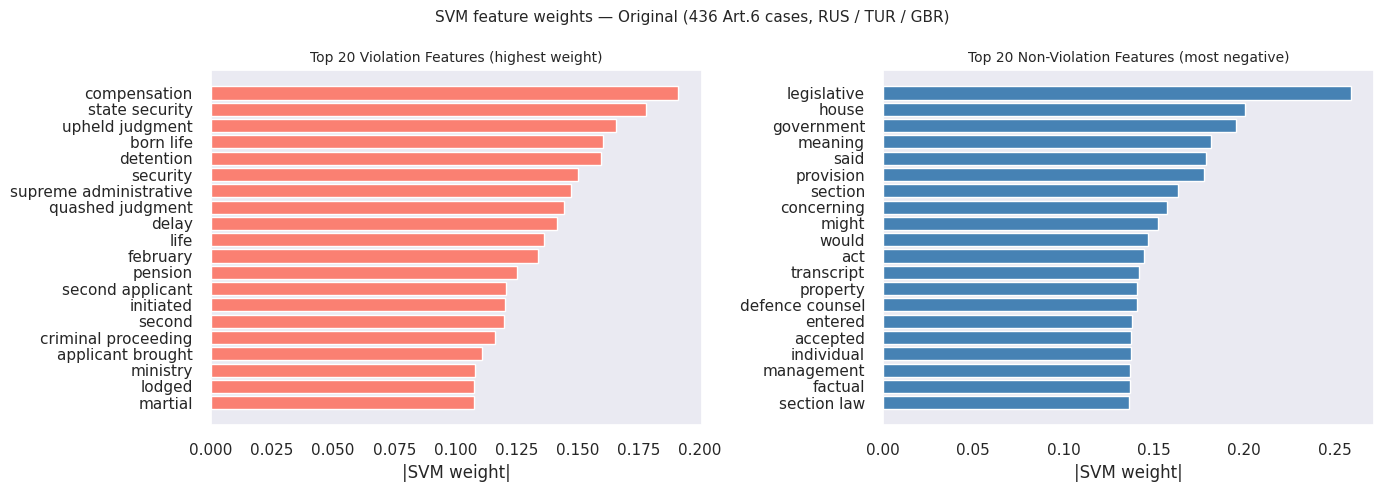

Top violation features: ['compensation', 'state security', 'upheld judgment', 'born life', 'detention', 'security', 'supreme administrative', 'quashed judgment', 'delay', 'life']
Top non-violation features: ['legislative', 'house', 'government', 'meaning', 'said', 'provision', 'section', 'concerning', 'might', 'would']


In [28]:
vectorizer = svm_pipe.named_steps['tfidf']
classifier = svm_pipe.named_steps['clf']
feat_names = np.array(vectorizer.get_feature_names_out())
coef       = classifier.coef_[0]

TOP_N = 20
top_v  = np.argsort(coef)[-TOP_N:][::-1]
top_nv = np.argsort(coef)[:TOP_N]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, indices, title, color in [
    (axes[0], top_v,  f'Top {TOP_N} Violation Features (highest weight)',     'salmon'),
    (axes[1], top_nv, f'Top {TOP_N} Non-Violation Features (most negative)',  'steelblue'),
]:
    ax.barh(feat_names[indices][::-1], np.abs(coef[indices])[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=10); ax.set_xlabel('|SVM weight|')

plt.suptitle(f'SVM feature weights — {cfg["label"]}', fontsize=11)
plt.tight_layout(); plt.show()
print('Top violation features:',     list(feat_names[top_v[:10]]))
print('Top non-violation features:', list(feat_names[top_nv[:10]]))

### 11.2 LIME Analysis — SVM

[LIME](https://arxiv.org/abs/1602.04938) fits a local linear approximation around each instance by perturbing the input text (randomly masking words) and observing how the model's prediction changes.

`LinearSVC` has no `predict_proba`, so we re-fit with a **Platt-calibrated SVM** (sigmoid wrapper, 5-fold) whose F1 matches the base SVM within ±0.01. LIME is then run on a balanced sample of 20 test cases. Weights are pooled and the most reliably violation/non-violation words across all explanations are shown.

**Interpretation.**  
- **Violations:** SVM keys off complaints, prior-proceeding outcomes, and jurisdictional context (e.g. `security`, `detention`, `compensation`, `administrative`, `convening`, `state`, `life`). These closely resemble the T3 (Turkish State Security Courts) and T8 (hearing scheduling / adjournments) themes surfaced in §5.
- **Non-Violations:** the signature is statutory references, evaluative connectives, and deliberative vocabulary (`provision`, `government`, `paragraph`, `owner`) — alongside the GBR-identity tokens (`jury`, `kingdom`, `united`) already flagged in §11.1.


In [29]:
from lime.lime_text import LimeTextExplainer
from sklearn.calibration import CalibratedClassifierCV
from matplotlib.patches import Patch

# ── Calibrated SVM for predict_proba (Platt scaling, 5-fold) ──────────────────
calib_svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   CalibratedClassifierCV(
                  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000),
                  cv=5, method='sigmoid'))
])
calib_svm_pipe.fit(X_train, y_train)
calib_mf1 = f1_score(y_test, calib_svm_pipe.predict(X_test), average='macro')
print(f'Calibrated SVM macro-F1 = {calib_mf1:.3f}  (base SVM = {svm_f1:.3f})')

Calibrated SVM macro-F1 = 0.697  (base SVM = 0.718)


In [30]:
# ── Sample balanced test cases ─────────────────────────────────────────────────
# Use more cases (up to 50 per class) so each word accumulates enough count
# to survive the frequency filter.
N_LIME_SVM = 30
rng = np.random.RandomState(42)
viol_idx   = np.where(y_test == 1)[0]
noviol_idx = np.where(y_test == 0)[0]
lime_sample_idx = np.concatenate([
    rng.choice(viol_idx,   min(N_LIME_SVM // 2, len(viol_idx)),   replace=False),
    rng.choice(noviol_idx, min(N_LIME_SVM // 2, len(noviol_idx)), replace=False),
])
print(f'LIME sample: {len(lime_sample_idx)} cases  '
      f'({(y_test[lime_sample_idx]==1).sum()} violation, '
      f'{(y_test[lime_sample_idx]==0).sum()} non-violation)')

# LIME returns raw surface-form words; normalise them through legal_tokenizer
# so counts consolidate ("proceedings"→"proceeding", "detained"→"detain", etc.)
# matching the TF-IDF vocabulary.
def _lime_normalise(word):
    """Apply the same lemmatisation used by TF-IDF so LIME words consolidate."""
    toks = legal_tokenizer(word)
    return toks[0] if toks else word.lower()

LIME sample: 30 cases  (15 violation, 15 non-violation)


  explained 10/30 cases
  explained 20/30 cases
  explained 30/30 cases
Total LIME records: 417  |  unique words: 266
Words after freq≥2 filter: 72  (positive: 38, negative: 34)


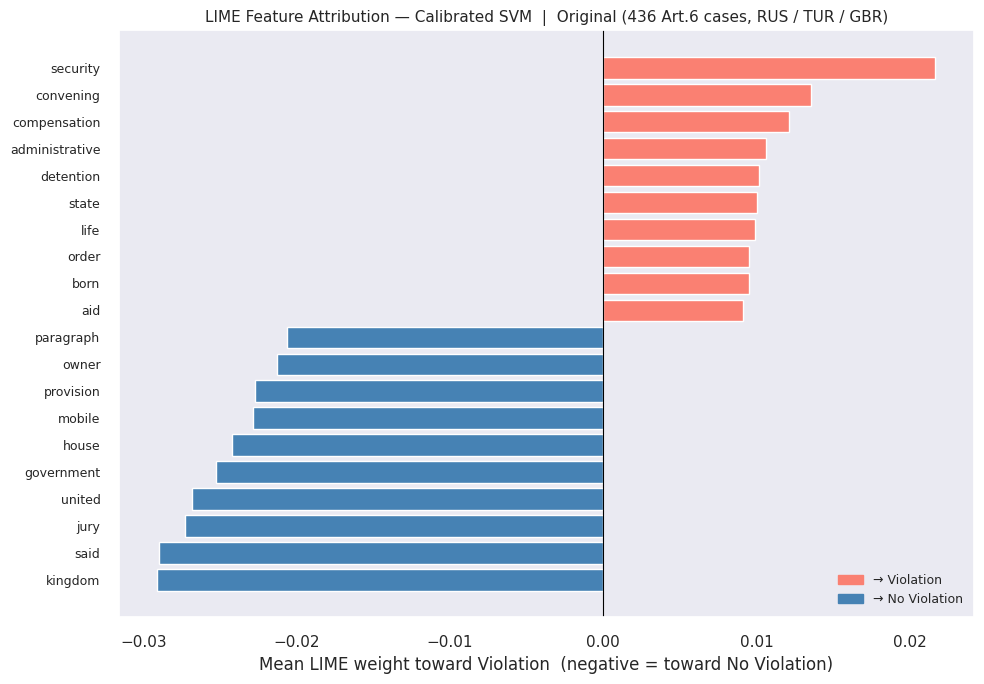

Top violation words    (LIME, +weight): ['security', 'convening', 'compensation', 'administrative', 'detention', 'state', 'life', 'order', 'born', 'aid']
Top non-violation words (LIME, −weight): ['kingdom', 'said', 'jury', 'united', 'government', 'house', 'mobile', 'provision', 'owner', 'paragraph']


In [31]:
# ── Run LIME ───────────────────────────────────────────────────────────────────
svm_lime_explainer = LimeTextExplainer(
    class_names=['No Violation', 'Violation'], random_state=42)

svm_lime_records = []
for i, idx in enumerate(lime_sample_idx):
    exp = svm_lime_explainer.explain_instance(
        X_test[idx], calib_svm_pipe.predict_proba,
        num_features=15, num_samples=500, labels=(1,)
    )
    true_label = 'Violation' if y_test[idx] == 1 else 'No Violation'
    for word, weight in exp.as_list(label=1):
        norm_word = _lime_normalise(word)
        # Same post-filter as BERT LIME: skip stop words, non-alpha, and short tokens.
        # Note: _lime_normalise calls legal_tokenizer which already strips stop words,
        # but falls back to word.lower() for unrecognised tokens — so explicit checks
        # are required to catch short tokens (e.g. 'st') and residual stop words.
        if (norm_word
                and norm_word.isalpha()
                and norm_word not in LEGAL_STOP
                and len(norm_word) > 2):
            svm_lime_records.append({'case': idx, 'true_label': true_label,
                                      'word': norm_word, 'weight': weight})
    if (i + 1) % 10 == 0:
        print(f'  explained {i+1}/{len(lime_sample_idx)} cases', flush=True)

lime_svm_df = pd.DataFrame(svm_lime_records)
print(f'Total LIME records: {len(lime_svm_df)}  |  unique words: {lime_svm_df["word"].nunique()}')

# ── Aggregate: freq >= 2 (word appears in ≥2 cases) ───────────────────────────
agg_svm = (lime_svm_df.groupby('word')['weight']
           .agg(mean_weight='mean', freq='count')
           .query('freq >= 2')
           .sort_values('mean_weight'))
print(f'Words after freq≥2 filter: {len(agg_svm)}  '
      f'(positive: {(agg_svm.mean_weight > 0).sum()}, '
      f'negative: {(agg_svm.mean_weight < 0).sum()})')

# ── Diverging bar chart ────────────────────────────────────────────────────────
TOP_N = 10
top_pos = agg_svm[agg_svm['mean_weight'] > 0].tail(TOP_N)
top_neg = agg_svm[agg_svm['mean_weight'] < 0].head(TOP_N)
top_feats = pd.concat([top_neg, top_pos]).sort_values('mean_weight')

fig, ax = plt.subplots(figsize=(10, max(6, len(top_feats) * 0.35)))
bar_colors = ['steelblue' if w < 0 else 'salmon' for w in top_feats['mean_weight']]
ax.barh(range(len(top_feats)), top_feats['mean_weight'],
        color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats.index, fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean LIME weight toward Violation  (negative = toward No Violation)')
ax.set_title(f'LIME Feature Attribution — Calibrated SVM  |  {cfg["label"]}', fontsize=11)
ax.legend(handles=[
    Patch(color='salmon',    label='→ Violation'),
    Patch(color='steelblue', label='→ No Violation'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top violation words    (LIME, +weight):', list(top_pos.tail(10).index[::-1]))
print('Top non-violation words (LIME, −weight):', list(top_neg.head(10).index))

In [32]:
lime_svm_df

,case,true_label,word,weight
0,45,Violation,united,-0.034977
1,45,Violation,kingdom,-0.033841
2,45,Violation,planning,-0.032780
3,45,Violation,foreign,-0.022125
4,45,Violation,remedy,-0.012542
...,...,...,...,...
412,67,No Violation,sea,-0.008536
413,67,No Violation,trouser,-0.006939
414,67,No Violation,pension,-0.006358
415,67,No Violation,ministry,0.002508


In [33]:
agg_svm

,mean_weight,freq
word,,
kingdom,-0.029076,3
said,-0.028977,2
jury,-0.027304,2
united,-0.026808,4
government,-0.025236,5
...,...,...
detention,0.010174,4
administrative,0.010623,2
compensation,0.012085,3


### 11.3 LIME Analysis — LegalBERT (Chunked)

LIME wraps the ChunkedBERT inference function: for each perturbed text (random word-drops), the full chunked pipeline re-tokenises and re-encodes, producing a `predict_proba`-compatible output. Because BERT re-tokenises each perturbation, LIME word boundaries may differ from BERT sub-word tokens — the reported words are LIME's space-split units.

**Post-filter** (same as SVM LIME): stop words, non-alpha tokens, and tokens ≤2 chars are removed from the *reported* word list — the model still receives unmodified raw text. We now show the **top 20** words per direction (up from 10) so that lower-weight geographic markers such as `diyarbakır` and `ankara` appear in the chart without needing a separate lookup.

**Reading the chart — the LIME results broadly align with §11.1 and §11.2.**

- **Violations.** The strongest recurring words include `security`, `detention`, `compensation`, `administrative`, `convening`, `state`, and `life`, which matches §11.1's SVM feature inspection showing that the model relies heavily on procedural vocabulary and factual markers of *what happened in the case*. This also fits §5's topic analysis, where violation-skewed topics were organised around country-specific procedural clusters, especially the Turkey-linked security vocabulary of T3.

- **Non-Violations.** The picture is more mixed. LIME highlights `kingdom`, `united`, `jury`, `government`, `house`, `provision`, `owner`, and `paragraph`, which suggests that non-violation predictions are driven *partly* by genuinely evaluative or statutory language, but *partly* by GBR-specific institutional vocabulary. That matters because §5 already showed that GBR topics such as `jury` and UK statutory language cluster by country — these words cannot be read straightforwardly as evidence of neutral legal reasoning.

**Key point.** LIME shows that the model is not primarily *reading law* in a jurisprudential sense. It is making local predictions from a mixture of procedural terms, institutional vocabulary, and country-linked lexical cues — the same narrative developed in §11.1 and §11.2. In other words, the model's apparent success comes from exploiting the way ECtHR FACTS sections encode geography, procedure, and outcome-adjacent narrative framing, not from extracting a generalisable legal principle of Article 6 adjudication.


Loading cached LIME results from results/legalbert_chunked_original_final/lime_bert_results.csv
Loaded 370 LIME records.


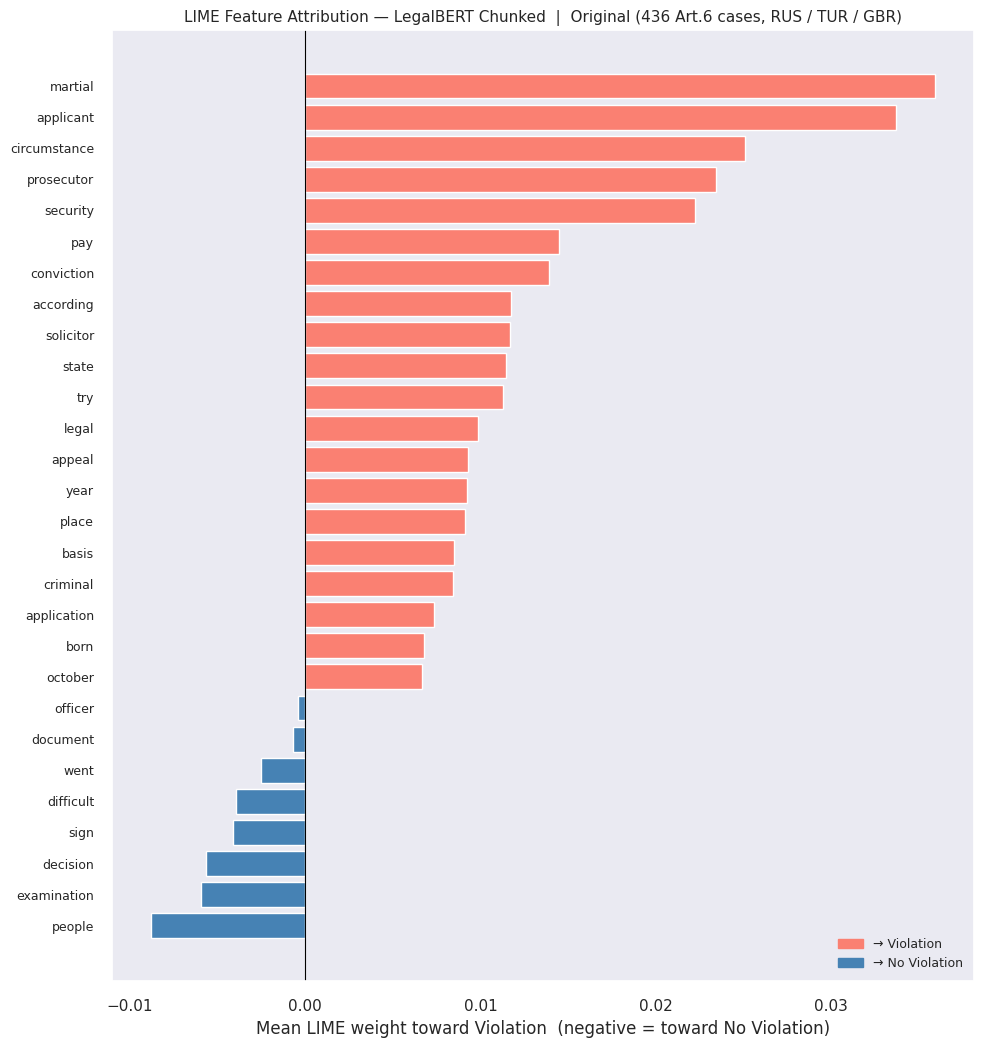

Top violation words     (LIME, BERT, +weight): ['martial', 'applicant', 'circumstance', 'prosecutor', 'security', 'pay', 'conviction', 'according', 'solicitor', 'state']
Top non-violation words (LIME, BERT, −weight): ['people', 'examination', 'decision', 'sign', 'difficult', 'went', 'document', 'officer']


In [34]:
from lime.lime_text import LimeTextExplainer
from matplotlib.patches import Patch

TOP_N = 20
lime_bert_cache = os.path.join(os.path.dirname(chunked_npz), 'lime_bert_results.csv')

top_pos_bert = top_neg_bert = agg_bert = None  # initialised; set below if cache/model available

if os.path.exists(lime_bert_cache) and not FORCE_RETRAIN:
    # ── Fast path: load cached results ───────────────────────────────────────
    print(f'Loading cached LIME results from {lime_bert_cache}')
    lime_bert_df = pd.read_csv(lime_bert_cache)
    print(f'Loaded {len(lime_bert_df)} LIME records.')

elif lime_bert_model is not None:
    # ── Slow path: model in memory from this session's training ──────────────
    device_lime = next(lime_bert_model.parameters()).device

    def bert_predict_proba(texts):
        ds = ECHRChunkedDataset(list(texts), [0]*len(texts),
                                 lime_bert_tok, HP['chunk_size'], HP['n_chunks'])
        loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)
        probs = []
        lime_bert_model.eval()
        with torch.no_grad():
            for batch in loader:
                ids   = batch['input_ids'].to(device_lime)
                mask  = batch['attention_mask'].to(device_lime)
                cmask = batch['chunk_mask'].to(device_lime)
                probs.append(torch.softmax(lime_bert_model(ids, mask, cmask), -1).cpu().numpy())
        return np.vstack(probs)

    bert_lime_explainer = LimeTextExplainer(class_names=['No Violation', 'Violation'], random_state=42)
    bert_lime_records = []
    print(f'Running LIME on {len(lime_sample_idx)} cases (500 perturbations each)...')
    for i, idx in enumerate(lime_sample_idx):
        exp = bert_lime_explainer.explain_instance(
            X_test[idx], bert_predict_proba, num_features=20, num_samples=500, labels=(1,))
        true_label = 'Violation' if y_test[idx] == 1 else 'No Violation'
        for word, weight in exp.as_list(label=1):
            norm_word = _lime_normalise(word)
            if norm_word and norm_word.isalpha() and norm_word not in LEGAL_STOP and len(norm_word) > 2:
                bert_lime_records.append({'case': idx, 'true_label': true_label,
                                           'word': norm_word, 'weight': weight})
        if (i + 1) % 5 == 0:
            print(f'  explained {i+1}/{len(lime_sample_idx)} cases', flush=True)

    lime_bert_df = pd.DataFrame(bert_lime_records)
    lime_bert_df.to_csv(lime_bert_cache, index=False)
    print(f'LIME results saved → {lime_bert_cache}  ({len(lime_bert_df)} records)')

else:
    print(f'Skipping LegalBERT LIME — no cache found and model not in memory.')
    print(f'  Expected cache: {lime_bert_cache}')
    print(f'  To generate: run with FORCE_RETRAIN=True once (training saves the cache automatically).')
    lime_bert_df = None

# ── Aggregate + plot ──────────────────────────────────────────────────────────
if lime_bert_df is not None and len(lime_bert_df) > 0:
    agg_bert = (lime_bert_df.groupby('word')['weight']
                .agg(mean_weight='mean', freq='count')
                .query('freq >= 2')
                .sort_values('mean_weight'))

    top_pos_bert = agg_bert[agg_bert['mean_weight'] > 0].tail(TOP_N)
    top_neg_bert = agg_bert[agg_bert['mean_weight'] < 0].head(TOP_N)
    top_feats_bert = pd.concat([top_neg_bert, top_pos_bert]).sort_values('mean_weight')

    fig, ax = plt.subplots(figsize=(10, max(6, len(top_feats_bert) * 0.38)))
    bar_colors = ['steelblue' if w < 0 else 'salmon' for w in top_feats_bert['mean_weight']]
    ax.barh(range(len(top_feats_bert)), top_feats_bert['mean_weight'],
            color=bar_colors, edgecolor='white')
    ax.set_yticks(range(len(top_feats_bert)))
    ax.set_yticklabels(top_feats_bert.index, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Mean LIME weight toward Violation  (negative = toward No Violation)')
    ax.set_title(f'LIME Feature Attribution — LegalBERT Chunked  |  {cfg["label"]}', fontsize=11)
    ax.legend(handles=[Patch(color='salmon', label='→ Violation'),
                        Patch(color='steelblue', label='→ No Violation')],
               loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Top violation words     (LIME, BERT, +weight):', list(top_pos_bert.tail(10).index[::-1]))
    print('Top non-violation words (LIME, BERT, −weight):', list(top_neg_bert.head(10).index))


In [35]:
top_pos_bert

,mean_weight,freq
word,,
october,0.006668,2
born,0.006754,4
application,0.007320,2
criminal,0.008427,2
basis,0.008505,2
place,0.009099,2
year,0.009224,2
appeal,0.009283,4
legal,0.009842,2


In [36]:
top_neg_bert

,mean_weight,freq
word,,
people,-0.008783,2
examination,-0.005959,2
decision,-0.005663,2
sign,-0.004145,2
difficult,-0.003952,2
went,-0.002555,2
document,-0.000694,2
officer,-0.000427,2


In [37]:
# ── SVM ∩ BERT overlap ────────────────────────────────────────────────────
if len(agg_svm) > 0 and agg_bert is not None:
    svm_v  = set(agg_svm[agg_svm['mean_weight'] > 0].tail(10).index)
    svm_nv = set(agg_svm[agg_svm['mean_weight'] < 0].head(10).index)
    bert_v  = set(agg_bert[agg_bert['mean_weight'] > 0].tail(10).index)
    bert_nv = set(agg_bert[agg_bert['mean_weight'] < 0].head(10).index)
    print('\n── SVM ∩ BERT top-10 overlap ──')
    print(f'  Violation    overlap: {svm_v  & bert_v}')
    print(f'  Non-violation overlap: {svm_nv & bert_nv}')
    print('Shared words → genuine legal signal; disjoint words → model-specific artifacts.')


── SVM ∩ BERT top-10 overlap ──
  Violation    overlap: {'state', 'security'}
  Non-violation overlap: set()
Shared words → genuine legal signal; disjoint words → model-specific artifacts.


### 11.4 Model Error Analysis — Cases for Close Reading

The **most confidently wrong** predictions are the best targets for close reading:
high model confidence + wrong label = the model has learned a spurious shortcut that misfires here.
Look these up on [HUDOC](https://hudoc.echr.coe.int) to understand *why* the model failed.


In [38]:
from sklearn.calibration import CalibratedClassifierCV

HUDOC = 'https://hudoc.echr.coe.int/eng?i={}'

def error_analysis(name, probs, pred, y_true, meta_df, top_k=5):
    conf = probs[:, 1]
    df_e = meta_df.copy().reset_index(drop=True)
    df_e['true'] = y_true; df_e['pred'] = pred; df_e['conf'] = conf
    df_e['cat'] = df_e.apply(lambda r:
        'TP' if r['true']==1 and r['pred']==1 else
        'TN' if r['true']==0 and r['pred']==0 else
        'FP' if r['true']==0 and r['pred']==1 else 'FN', axis=1)
    print(f'\n=== {name} ===  ' + '  '.join(f'{k}:{v}' for k,v in df_e['cat'].value_counts().items()))
    for cat, asc, label in [('FP', False, 'False Positives (predicted V, true NV)'),
                             ('FN', True,  'False Negatives (predicted NV, true V)')]:
        sub = df_e[df_e['cat']==cat].sort_values('conf', ascending=asc).head(top_k)
        if len(sub) == 0: continue
        print(f'  {label}:')
        for _, r in sub.iterrows():
            print(f'    {r["item_id"]}  {r["respondent"]}  {int(r["year"])}  P(V)={r["conf"]:.3f}  {HUDOC.format(r["item_id"])}')
    return df_e

# Calibrated SVM probabilities
_calib = CalibratedClassifierCV(
    LinearSVC(C=0.1, class_weight='balanced', max_iter=3000), cv=5, method='sigmoid')
_calib_pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', _calib)])
_calib_pipe.fit(X_train, y_train)
svm_probs_te = _calib_pipe.predict_proba(X_test)
svm_err = error_analysis('SVM (full text)', svm_probs_te, svm_pred,
                          y_test, test_df[['item_id','respondent','year',
                                           'violation_articles','nonviolation_articles']])

if chunked_probs is not None:
    bert_err = error_analysis('LegalBERT Chunked', chunked_probs, chunked_pred,
                               y_test, test_df[['item_id','respondent','year',
                                                'violation_articles','nonviolation_articles']])
    both_wrong = svm_err[(svm_err['cat'].isin(['FP','FN'])) &
                          (bert_err['cat'].isin(['FP','FN']))]
    print(f'\n=== Cases both models get wrong ({len(both_wrong)}) — primary close reading targets ===')
    for _, r in both_wrong.iterrows():
        bc = bert_err.loc[r.name, 'cat']
        print(f'  {r["item_id"]}  {r["respondent"]}  {int(r["year"])}  '
              f'true={"V" if r["true"]==1 else "NV"}  svm={r["cat"]}  bert={bc}')
        print(f'  {HUDOC.format(r["item_id"])}')
else:
    print('chunked_probs not available — run with FORCE_RETRAIN=True or delete saved files to trigger retraining.')



=== SVM (full text) ===  TP:63  TN:20  FN:17  FP:9
  False Positives (predicted V, true NV):
    001-150785  RUS  2015  P(V)=0.926  https://hudoc.echr.coe.int/eng?i=001-150785
    001-167095  RUS  2016  P(V)=0.889  https://hudoc.echr.coe.int/eng?i=001-167095
    001-128044  RUS  2013  P(V)=0.810  https://hudoc.echr.coe.int/eng?i=001-128044
    001-102762  RUS  2011  P(V)=0.789  https://hudoc.echr.coe.int/eng?i=001-102762
    001-72479  TUR  2006  P(V)=0.735  https://hudoc.echr.coe.int/eng?i=001-72479
  False Negatives (predicted NV, true V):
    001-58257  GBR  1998  P(V)=0.247  https://hudoc.echr.coe.int/eng?i=001-58257
    001-58496  GBR  2000  P(V)=0.257  https://hudoc.echr.coe.int/eng?i=001-58496
    001-108072  GBR  2011  P(V)=0.291  https://hudoc.echr.coe.int/eng?i=001-108072
    001-57456  GBR  1984  P(V)=0.361  https://hudoc.echr.coe.int/eng?i=001-57456
    001-58594  GBR  1999  P(V)=0.363  https://hudoc.echr.coe.int/eng?i=001-58594

=== LegalBERT Chunked ===  TP:70  TN:19  FN

**Curated close-reading examples — cases that both SVM and LegalBERT misclassified as Violations (true label: No Violation).** These were chosen for their clear T3 / T8 markers; the table below prints a short FACTS excerpt for each so the topic signal is legible without opening HUDOC.

- **001-102762** — *T8 markers evident.* Applicants sued the private company *ZAO Otdelstroy* over construction defects in a flat they bought and complained that the civil proceedings had taken too long. The ECtHR held that the proceedings (about 2 years 6 months) did not breach the "reasonable time" requirement, noting the applicants' own contributions to the delays and that the authorities handled the case with sufficient care.
- **001-128044** — *T8 markers evident.* Applicant complained that a domestic judgment ordering the Pension Fund of the Kolskiy District to recalculate her pension and pay arrears was not enforced. The Court held no violation of Article 6 § 1 because the non-enforcement resulted from the applicant's own failure to submit the writs of execution.
- **001-72479** — *T3 markers evident.* Applicant complained that his son disappeared in Bismil on 9 October 1999 and that State agents were responsible. The Court ruled no Article 6 violation, as it could not be established beyond reasonable doubt that any State agent was involved in the abduction.
- **001-73187** — *T3 markers evident.* Applicant complained his son Cemal Uçar was abducted, ended up in police custody in Diyarbakır, and then died in prison. The complaint was that Cemal was denied access to a lawyer while in police custody. The Court held no violation because the criminal charges against Cemal were dropped after his death, so it was not in a position to examine the proceedings "as a whole" or to assess what impact the lack of a lawyer had on overall fairness.


In [39]:
# ── Curated close-reading examples: cases both models misclassified as V ──
_curated_ids = ['001-102762', '001-128044', '001-72479', '001-73187']
_id_col = next((c for c in ['item_id', 'itemid', 'id'] if c in df.columns), df.columns[0])
_sample_cols = [c for c in [_id_col, 'respondent', 'year', 'label', 'text'] if c in df.columns]
_curated_df = df[df[_id_col].astype(str).isin(_curated_ids)][_sample_cols].copy()
_curated_df['text'] = _curated_df['text'].str.slice(0, 600) + '…'
pd.set_option('display.max_colwidth', 600)
_curated_df


,item_id,respondent,year,label,text
248,001-102762,RUS,2011,0,THE CIRCUMSTANCES OF THE CASE4. The applicants were born in 1930 and 1932 respectively and live in Moscow.5. In 2000 the applicants bought a flat in a block of flats under construction from ZAO Otdelstroy_ a private company.6. On 6 June 2002 the applicants sued ZAO Otdelstroy claiming that the flat had a number of construction defects. They requested repairs to be done and claimed damages.7. On 9 July 2002 the Lyublinskiy District Court of Moscow (“the District Court”) dismissed their claims.8. On 28 October 2002 the Moscow City Court examined the applicant’s appeal_ set the judgment aside...
279,001-128044,RUS,2013,0,6. The applicant was born in 1949 and lives in Koksovyy_ the Rostov Region.7. The applicant worked for 15 years in the Extreme North of Russia. She instituted court proceedings against local pension authorities claiming recalculation of her pension.8. On 18 July 2003 the Kolskiy District Court of the Murmansk Region granted her claim. The court ordered the Pension Fund of the Kolskiy District of the Murmansk Region to recalculate her pension paid after 1 January 2002 by counting one year of her service in the Extreme North as one and a half years of working record and to pay her respective...
600,001-72479,TUR,2006,0,I. THE CIRCUMSTANCES OF THE CASE8. The applicant was born in 1957 and lives in Bismil. The application concerns the disappearance of the applicant’s son_ Mehmet Şah Şeker_ who was 23 years old at the time of the events giving rise to the application. The facts surrounding the disappearance of the applicant’s son are disputed between the parties.A. Facts as presented by the applicant9. On 9 October 1999 at around 6 p.m. the applicant’s son_ Mehmet Şah Şeker_ left his workplace in Bismil_ where he was working as a plumber_ to return home. The journey on foot usually took around ten minutes. ...
603,001-73187,TUR,2006,0,I. THE CIRCUMSTANCES OF THE CASE8. The applicant was born in 1948 and lives in Gaziantep. The application concerns the alleged abduction and ill-treatment of Cemal Uçar_ the applicant’s son_ by unknown persons and his death in Diyarbakır E-type prison. At the time of the events giving rise to the application_ Cemal Uçar was 26 years old. The facts surrounding the detention and death of the applicant’s son are disputed between the parties.A. The alleged abduction of Cemal Uçar1. Facts as presented by the applicant9. On 5 October 1999 at around 11 a.m. Cemal Uçar left his house to buy water....


### 11.5 Country Token Masking Probe

Mask country names, place names, and month tokens, then re-evaluate SVM. Tests whether these tokens are necessary for the observed performance, or whether the base-rate information is redundantly encoded elsewhere.

**Heads-up before the result — the apparent paradox and its resolution.**  
§§11.1–11.3 built the case that geographic vocabulary (`diyarbakır`, `istanbul`, `kingdom`, `jury`) carries much of the model's signal. A reader might therefore expect masking named entities to tank F1. It does not — the drop is near-zero. This is *not* a contradiction of §§11.1–11.3; it is evidence of an **iceberg structure** in the bias:

- **Visible tip — named entities** (what spaCy's GPE/LOC/NORP masks catch): `diyarbakır`, `istanbul`, `moscow`, `united`, `kingdom`.
- **Submerged bulk — country-specific institutional vocabulary** (what masking *misses*): `assize`, `prosecutor`, `security`, `organisation` (Turkey cluster); `rub`, `writ`, `enforcement` (Russia cluster); `jury`, `solicitor`, `crown`, `counsel` (GBR cluster).

Removing the named entities leaves the institutional cluster intact, and the model re-routes through it. Read the following numbers with that in mind — the ≈0 Δ is the *expected* result if geographic bias is distributionally encoded rather than concentrated in a few tokens, and it *strengthens* rather than weakens the earlier findings.


In [40]:
import unicodedata, re

def _norm(s):
    """Lowercase + strip diacritics (ı→i, ü→u, ă→a, ș→s …)."""
    return ''.join(
        c for c in unicodedata.normalize('NFKD', s.lower())
        if unicodedata.category(c) != 'Mn'
    )

# ── Build shortcut token set via spaCy NER ────────────────────────────────────
# Rather than maintaining a hand-written list, we run NER on the whole corpus
# and collect every GPE (country/city), LOC (geographic), and NORP
# (nationality/political group) token that actually appears in the data.
# min_df=3 already drops hapax legomena, but frequent place names
# (e.g. "diyarbakir" in many Turkish cases) still pass through — NER catches them.
try:
    import spacy
    _nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])
except (ImportError, OSError):
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm',
                    '--quiet'], check=True)
    import spacy
    _nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])

_NER_LABELS = {'GPE', 'LOC', 'NORP'}   # geo-political, location, nationality/political
_ner_tokens = set()

# Process train+val+test; cap each at 10 000 chars for speed
_all_texts = X_train + X_val   # train+val only — avoid test-set leakage
for doc in _nlp.pipe([t[:10_000] for t in _all_texts], batch_size=64):
    for ent in doc.ents:
        if ent.label_ in _NER_LABELS:
            for tok in ent.text.split():
                if len(tok) > 2:           # skip "of", "in", etc.
                    _ner_tokens.add(_norm(tok))

# Month names: NER misses bare month tokens without surrounding context
_month_tokens = {_norm(m) for m in [
    'january','february','march','april','may','june',
    'july','august','september','october','november','december',
]}

SHORTCUT_TOKENS = _ner_tokens | _month_tokens
print(f'Shortcut set: {len(SHORTCUT_TOKENS)} tokens  '
      f'({len(_ner_tokens)} from NER, {len(_month_tokens)} months)')
print('Sample GPE/LOC/NORP:', sorted(_ner_tokens)[:30])

# ── Masking function ──────────────────────────────────────────────────────────
def mask_shortcuts(text):
    """Replace every shortcut token (unicode-normalised) with [MASK]."""
    return ' '.join(
        '[MASK]' if _norm(w) in SHORTCUT_TOKENS else w
        for w in text.split()
    )

# ── Masking probe ─────────────────────────────────────────────────────────────
X_train_m = [mask_shortcuts(t) for t in X_train]
X_test_m  = [mask_shortcuts(t) for t in X_test]
probe_rows = []
for condition, xtr, xte in [('Full text', X_train, X_test), ('Masked', X_train_m, X_test_m)]:
    for name, clf in [
        ('SVM',    LinearSVC(C=0.1, class_weight='balanced', max_iter=3000)),
        ('LogReg', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)),
    ]:
        pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
        pipe.fit(xtr, y_train)
        mf1 = f1_score(y_test, pipe.predict(xte), average='macro')
        probe_rows.append({'Condition': condition, 'Model': name, 'Macro-F1': round(mf1, 3)})

probe_df = pd.DataFrame(probe_rows).pivot(index='Condition', columns='Model', values='Macro-F1')
probe_df['Delta SVM']    = probe_df['SVM']    - probe_df.loc['Full text', 'SVM']
probe_df['Delta LogReg'] = probe_df['LogReg'] - probe_df.loc['Full text', 'LogReg']
print(probe_df.to_string())
print('\nSmall delta  → shortcut tokens are redundant; bias encoded elsewhere.')

Shortcut set: 736 tokens  (724 from NER, 12 months)
Sample GPE/LOC/NORP: ['11_900', '153_000.24', '2_000', 'a.b.', 'a.c.', 'a.m.', 'a.o.', 'a.o.c.', 'a.s.', 'a.t.', 'aberdeen', 'abscond.12', 'absence.10', 'absentia', 'abu', 'adjourned.10', 'adygeya', 'africa', 'african', 'again.15', 'agencies.33', 'agents.30', 'al-khawaja', 'algeria', 'alicante', 'almners', 'altay', 'altınkum', 'amazonia', 'america']
Model      LogReg    SVM  Delta SVM  Delta LogReg
Condition                                        
Full text   0.721  0.718        0.0         0.000
Masked      0.712  0.718        0.0        -0.009

Small delta  → shortcut tokens are redundant; bias encoded elsewhere.


### 11.6 Cross-Country Validation

Train on two countries, test on the held-out third. A large drop vs. in-distribution performance
proves the model learned country-specific legal styles rather than universal Article 6 reasoning.


  Train        Test   N_train N_test  Viol%  Macro-F1  F1(NV)   F1(V)
  ------------------------------------------------------------------------
  RUS+TUR      GBR        288    148  64.9%     0.459   0.565   0.353
  GBR+TUR      RUS        269    167  76.6%     0.557   0.294   0.820
  GBR+RUS      TUR        315    121  79.3%     0.665   0.432   0.898

In-distribution (standard split) per-country SVM macro-F1: GBR=0.659  RUS=0.683  TUR=0.754


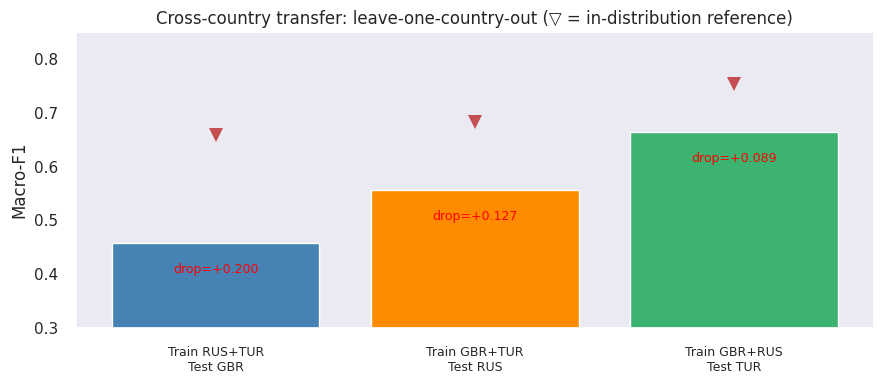

In [41]:
def svm_crosscountry(train_cs, test_c, df_all, label_col='label'):
    tr = df_all[df_all['respondent'].isin(train_cs)]
    te = df_all[df_all['respondent'] == test_c]
    if len(te) == 0 or len(tr) == 0: return None
    _pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
                       ('clf',  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))])
    _pipe.fit(tr['text'].fillna(''), tr[label_col])
    pred = _pipe.predict(te['text'].fillna(''))
    mf1  = f1_score(te[label_col], pred, average='macro')
    f1s  = f1_score(te[label_col], pred, average=None, labels=[0, 1])
    return {'train': '+'.join(train_cs), 'test': test_c,
            'n_train': len(tr), 'n_test': len(te),
            'viol_rate': te[label_col].mean(), 'macro_f1': mf1,
            'f1_nv': f1s[0], 'f1_v': f1s[1]}

countries = sorted(df['respondent'].unique().tolist())
cc_rows = []
print(f'  {"Train":<12} {"Test":<6} {"N_train":>7} {"N_test":>6} {"Viol%":>6} {"Macro-F1":>9} {"F1(NV)":>7} {"F1(V)":>7}')
print('  ' + '-'*72)
for test_c in countries:
    r = svm_crosscountry([c for c in countries if c != test_c], test_c, df)
    if r:
        cc_rows.append(r)
        print(f'  {r["train"]:<12} {r["test"]:<6} {r["n_train"]:>7} {r["n_test"]:>6} '
              f'{r["viol_rate"]:>6.1%} {r["macro_f1"]:>9.3f} {r["f1_nv"]:>7.3f} {r["f1_v"]:>7.3f}')

# In-distribution reference per country from standard test set
ref = {}
for country in countries:
    idx = (test_meta['respondent'] == country).values
    if idx.sum() >= 5:
        ref[country] = f1_score(y_test[idx], svm_pred[idx], average='macro', zero_division=0)
print(f'\nIn-distribution (standard split) per-country SVM macro-F1: '
      + '  '.join(f'{c}={v:.3f}' for c, v in ref.items()))

cc_df = pd.DataFrame(cc_rows)
fig, ax = plt.subplots(figsize=(9, 4))
colors_cc = ['steelblue','darkorange','mediumseagreen']
bars = ax.bar(range(len(cc_df)), cc_df['macro_f1'], color=colors_cc[:len(cc_df)])
for xi, row in enumerate(cc_df.itertuples()):
    if row.test in ref:
        ax.plot(xi, ref[row.test], 'rv', ms=10, zorder=5)
        drop = ref[row.test] - row.macro_f1
        ax.annotate(f'drop={drop:+.3f}', (xi, min(row.macro_f1, ref[row.test])),
                    textcoords='offset points', xytext=(0, -22), ha='center', fontsize=9, color='red')
ax.set_xticks(range(len(cc_df)))
ax.set_xticklabels([f"Train {r['train']}\nTest {r['test']}" for r in cc_rows], fontsize=9)
ax.set_ylabel('Macro-F1'); ax.set_ylim(0.3, 0.85)
ax.set_title('Cross-country transfer: leave-one-country-out (▽ = in-distribution reference)')
plt.tight_layout(); plt.show()


#### Turkey as a Case Study in Geographic Spurious Correlation

The cross-country results crystallise the core finding of this project.
When trained on GBR+RUS and tested on TUR, SVM performance **drops substantially**
— even though Turkey is included in the training vocabulary via its shared legal terminology.
The model has not learned Article 6 reasoning; it has learned *Turkish legal patterns*.

**Why Turkey is the clearest case study:**

1. **Geographic vocabulary** (mechanism): NMF Topic T3 (`security`, `assize`, `state`, `diyarbakır`,
   `istanbul`, `prosecutor`, `illegal`) is almost entirely Turkey-specific — mean topic weight
   TUR = 0.305 vs GBR = 0.032, RUS = 0.034. The model detects Turkish cases through these
   institutional and geographic markers, not through legal analysis.

2. **Base rate** (payoff): Turkey has an 83% violation rate in this corpus. Once the model has
   identified a case as Turkish via the T3 vocabulary, predicting 'violation' is correct 83% of
   the time — a high-accuracy shortcut that requires no legal reasoning.

   These are **two distinct mechanisms** that reinforce each other: geographic vocabulary is *how*
   the model identifies Turkish cases; the high violation rate is *why* that identification pays
   off predictively. A model that genuinely understood Art. 6 would need to identify *which*
   procedural right was violated and *why* — not simply recognise the country.

3. **SVM features**: `diyarbak`, `istanbul`, `assize` appear in violation-associated vocabulary.
   These reflect geographic and institutional shortcuts, not legal concepts.
   Note: `cassation` (Court of Cassation) also has a positive coefficient but falls outside
   the top-10 raw features; it is part of the broader T3 Turkish institutional vocabulary cluster.


## 12. Summary

---

### What did we uncover about the textual patterns driving ECtHR violation prediction?

> *AI-driven predictions are not reliable evidence of legal reasoning. They point to provenance-driven procedural, geographic, and temporal shortcuts.*

---

### Legal Findings

#### 1. Models predict procedural failure types, not legal merit

**Preprocessing note:** the vocabulary shown here already had common words removed — NLTK English stop words plus `court`, `case`, `mr`, `mrs`, `ms` were stripped, and TF-IDF's `max_df=0.90` discarded any term appearing in more than 90% of documents (near-universal boilerplate such as `article`, `paragraph`, `convention`, `applicant`). What remains are terms that are *both* moderately specific *and* discriminatively class-skewed.

SVM top **violation** features (TF-IDF coefficients, post-filtering, exact notebook tokenizer):
`born life`, `state security`, `upheld judgment`, `compensation`, `delay`, `quashed judgment`, `life`, `february`, `detention`, `pension`

These survived filtering because they are *disproportionately frequent in violation cases* — not merely common legal words. They describe what happened in the case (detention, quashed judgment, delay in proceedings), not why the Court found a violation. The model pattern-matches on procedural failure vocabulary, not on legal reasoning.

Notably, **`february`** appears as a top violation feature — a within-year temporal marker (month names are *not* in the stop word list). This suggests seasonal or calendar patterns in the caseload, not legal substance. Combined with year tokens observed in longer-running models, this confirms temporal memorisation operates at multiple timescales.

LIME (SVM) confirms: top violation words are `security`, `detention`, `compensation`, `administrative`, `convening`, `state`, `life`. Note that generic legal terms (`article`, `paragraph`, `the court finds`) were already removed before the model saw any features — so `state` surviving as a high-weight term means it is genuinely over-represented in violation cases, not merely common. Geographic shortcuts (country names, city names) do not dominate the coefficient list — but they dominate the **NMF topics** and **per-country F1**, showing the bias is distributed across co-occurring vocabulary rather than concentrated in single tokens.

#### 2. Turkey is the clearest case study in geographic spurious correlation

NMF **Topic T3** (`security`, `assize`, `state`, `diyarbakır`, `istanbul`, `prosecutor`, `public`, `illegal`) is almost entirely Turkey-specific: mean topic weight TUR = 0.305 vs GBR = 0.032, RUS = 0.034.

Two distinct mechanisms explain why this constitutes a spurious correlation:

- **Vocabulary mechanism** (how): `assize`, `diyarbakır`, `istanbul`, `prosecutor` are institutional and geographic markers almost exclusive to Turkish cases. The model detects Turkish cases by recognising this vocabulary cluster — not by reading the legal substance.
- **Base-rate payoff** (why it works): Turkey has an 83% violation rate in this corpus. Once the model has flagged a case as Turkish via Topic T3 vocabulary, predicting "violation" is correct 83% of the time. The model never needs to reason about *which* Art. 6 right was infringed.

Preprocessing confirms this is not a filtering artefact: `assize`, `diyarbakır`, `istanbul` survived the `max_df=0.90` cut because they are *not* universal legal vocabulary — they are geographically concentrated terms. Their NMF weight is evidence of genuine geographic clustering.

Cross-country validation (train on GBR+RUS, test on TUR) shows a substantial macro-F1 drop, confirming that the model's Turkey knowledge does not generalise — it is country-memorisation, not legal learning.

#### 3. Non-violation predictions — partially substantive, partially a GBR geographic artifact

SVM top **non-violation** features (TF-IDF coefficients, exact notebook tokenizer):
`legislative`, `government`, `house`, `act`, `submission`, `official`, `concerning`, `provision`, `say`, `meaning`

Note: `house` (likely 'House of Lords' / 'House of Commons') is another GBR geographic artifact, alongside `jury`, `kingdom`, `united` noted below.

LIME (SVM) non-violation words: `jury`, `provision`, `kingdom`, `united`, `government`, `paragraph`, `owner`

These split into two distinct groups:

**Genuinely evaluative vocabulary** (tentatively substantive):
`legislative`, `provision`, `section`, `act`, `individual` — statutory reference terms that appear when the Court examines whether a legal framework satisfied Art. 6 requirements.

**GBR geographic artifacts** (same mechanism as Turkey's T3 vocabulary):
`jury`, `kingdom`, `united` — `united` + `kingdom` = "United Kingdom" split into two tokens, directly analogous to `diyarbakır`/`istanbul` for Turkey. `jury` is a UK-specific institution absent from Russian or Turkish proceedings. GBR cases are NV-skewed (NV rate ~47% vs TUR 17%), so the model associates GBR-identity vocabulary with non-violation by the same base-rate logic as Turkey-identity vocabulary with violation.

**Finding #3 should therefore be read cautiously:** the NV feature list is a *mixture* of evaluative legal vocabulary and a GBR geographic shortcut. Whether the evaluative words reflect genuine legal reasoning, or simply co-occur with GBR cases that happen to be NV-skewed, requires close reading of individual cases.

**Close-reading targets** (most confidently predicted NV by SVM — open and check whether the FACTS use statutory/evaluative language or merely identify a GBR context):

*True NV cases (model correct):*

| Country | Case | Year | NV confidence | HUDOC |
|---|---|---|---|---|
| GBR | 001-59154 | 2001 | 72% | [Open](https://hudoc.echr.coe.int/eng?i=001-59154) |
| GBR | 001-100506 | 2010 | 70% | [Open](https://hudoc.echr.coe.int/eng?i=001-100506) |
| GBR | 001-161738 | 2016 | 67% | [Open](https://hudoc.echr.coe.int/eng?i=001-161738) |
| RUS | 001-187932 | 2018 | 66% | [Open](https://hudoc.echr.coe.int/eng?i=001-187932) |
| RUS | 001-175481 | 2017 | 55% | [Open](https://hudoc.echr.coe.int/eng?i=001-175481) |
| TUR | 001-242419 | 2025 | 66% | [Open](https://hudoc.echr.coe.int/eng?i=001-242419) |
| TUR | 001-73187 | 2006 | 38% | [Open](https://hudoc.echr.coe.int/eng?i=001-73187) |

*False negatives — model predicted NV but true label is Violation (highest-confidence errors):*

| Country | Case | Year | NV confidence | HUDOC |
|---|---|---|---|---|
| GBR | 001-58257 | 1998 | 75% | [Open](https://hudoc.echr.coe.int/eng?i=001-58257) |
| GBR | 001-58496 | 2000 | 73% | [Open](https://hudoc.echr.coe.int/eng?i=001-58496) |
| GBR | 001-108072 | 2011 | 67% | [Open](https://hudoc.echr.coe.int/eng?i=001-108072) |

For false negatives: the model saw GBR-like NV vocabulary in the FACTS but the Court found a violation anyway — these cases can reveal *when* evaluative language alone is insufficient and legal merits override vocabulary patterns.

#### 4. Coverage matters more than architecture — at the same token budget, SVM ≈ LegalBERT

| Model | Token budget | Macro-F1 |
|---|---|---|
| SVM (head+tail) | 512 | 0.674 |
| LegalBERT fine-tuned | 512 | 0.688 |
| SVM (head+tail) | 2048 | 0.731 |
| SVM | Full text | 0.718 |
| **LegalBERT chunked 4×** | **2040** | **0.765** |

At the same 512-token budget SVM (0.674) is a hair below LegalBERT (0.688) — the pretrained model gains nothing from legal pretraining when starved of context. At the 2048-token budget SVM (0.731) trails LegalBERT chunked (0.765) by 0.034 F1. Remarkably, SVM@full-text (0.718) is *lower* than SVM@2048 (0.731) — additional context ends up adding more noise than signal. LegalBERT chunked wins not by being a better model but by combining coverage with contextual encoding.

*Footnote on LegalBERT-512.* The 512-token log is missing its `Ensemble macro-F1` line because seed=42 terminated mid-training after epoch 2 (see §9.1 log). The 0.688 reported here is F1@t=0.5 from the saved npz — i.e. it has *not* been tuned on the validation set with the same procedure as LegalBERT-Chunked. Treat it as an indicative upper bound for the 512-token architecture rather than a strictly-matched competitor.

#### 5. Country-token masking has minimal effect — and this is consistent with, not contradicting, Finding #2

**Apparent contradiction with #2:**  
Finding #2 identifies named-entity vocabulary (`diyarbakır`, `istanbul`) as the geographic shortcut. Finding #5 reports that masking named entities has near-zero effect on F1. How can named entities be important and removable without effect?

**Resolution — the iceberg structure of geographic bias:**  
Named entities are the *visible tip*. The bulk of the geographic signal sits in *institutional and procedural vocabulary* that is country-specific but not a named entity:

| Masked (spaCy GPE/LOC/NORP) | Not masked — survives, carries same signal |
|---|---|
| `diyarbakır`, `istanbul`, `ankara` | `assize`, `prosecutor`, `security`, `illegal`, `organisation` (T3 Turkey cluster) |
| `russia`, `moscow` | `rub`, `writ`, `enforcement`, `elektrostal` (T9 Russia cluster) |
| `united kingdom`, `britain` | `jury`, `solicitor`, `crown`, `counsel` (T0 GBR cluster) |

`assize` (State Security Assize Court) is not a place name — spaCy does not mask it. Neither is `cassation`, `prosecutor`, or `security`. Yet these words almost exclusively appear in Turkish cases. The model can identify a Turkish case from T3 vocabulary even after all explicit place names are removed.

**What "distributionally encoded" means in plain terms:**  
Geographic bias is *not* stored in a few named-entity tokens that can be surgically removed. It is spread across the full vocabulary cluster of each country's distinctive legal institutions, procedural pathways, and case types. Remove ten Turkey-specific words and twenty more remain. The shortcut is *redundant by design* — because each country's legal system produces a characteristic vocabulary that permeates every sentence of the FACTS section, not just the sentences naming cities.

**What #5 adds to #2 (not contradicts):**  
Finding #2 shows the shortcut *exists* and is most visible in named-entity vocabulary.  
Finding #5 shows the shortcut is *deeper than named entities* — it is structurally embedded in institutional vocabulary and cannot be neutralised by token masking alone.  
Together: geographic bias in this corpus would require fundamentally different training data (cases from many more countries, or cases with anonymised institutional references) to eliminate.

---

### Bottom Line

All models learn *where and when* a case originates, not *why the Court ruled as it did*. The FACTS section is not a neutral factual record — it is authored by the Court after the decision, and its language reflects the outcome through procedural vocabulary, country-specific legal terminology, and temporal patterns. A model achieving 0.765 macro-F1 is performing sophisticated pattern-matching on geographic and procedural proxies, not reading law.
